<a href="https://colab.research.google.com/github/Loading-my-brain/GEOG761_Remote_Sensing/blob/main/Labs/Hinami_Lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Introducing GeoAI
In the words of the developers themselves:
"GeoAI is a comprehensive Python package designed to bridge artificial intelligence (AI) and geospatial data analysis, providing researchers and practitioners with intuitive tools for applying machine learning techniques to geographic data. The package offers a unified framework for processing satellite imagery, aerial photographs, and vector data using state-of-the-art deep learning models. GeoAI integrates popular AI frameworks including PyTorch, Transformers, PyTorch Segmentation Models, and specialized geospatial libraries like torchange, enabling users to perform complex geospatial analyses with minimal code."
- [GeoAI 2025](https://opengeoai.org/)


The aim of the this lab is take the knowldege of fundamental mechanics in both satellite data and AI that you have this far gained- and apply them via the bridge that GeoAI provides.

This lab is a modified version of the following tutorial:
- [GeoAI Workshop 2025](https://www.youtube.com/watch?v=jdK-cleFUkc&ab_channel=OpenGeospatialSolutions)

A key thing to be aware of- we are stepping away here from using the GEE API, and taking a pure Python approach. So we have to go get our own data, and all our processing is happening on our 'local'.


earthengine-ml-testing-502922

# Task 1: mapping surface water with S2
We start by installing the required package and setting CoLab to run on a GPU. Until now, we have been running all our code on a CPU, a GPU allows us to use neural networks much more effectively.



To use GPU, please click the "Runtime" menu and select "Change runtime type". Then select "T4 GPU" from the dropdown menu. GPU acceleration is highly recommended for training deep learning models, as it can reduce training time from hours to minutes. It may already be set to this, but check!

If you are running this lab on your own laptop, follow the installation instructions linked below in order to ensure that GPU and subsequent CUDA usage is connected up correctly [people using Colab, no need to do so]:
- https://opengeoai.org/installation/
- https://aibook.gishub.org/book/foundations/setup/


First we will test to make sure our GPU is working in Colab. The cell below should produce something like:

```
PyTorch: 2.x.x
CUDA available: True
GPU: Tesla T4
```

If it does not, check that your runtime is set to a T4 GPU. If it is set to that and is still not using the CUDA and T4, restart the runtime.

In [ ]:
# Check Colab GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError(
        "No CUDA GPU detected. Select Runtime > Change runtime type > T4 GPU."
    )

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


Next we install Geo-AI:

In [ ]:
# Install GeoAI
%pip install -q geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.5/651.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.4/812.4 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8

And now we import and test that they are going to play nice together. The following should be the reported status:



```
GeoAI: 0.4x.x
PyTorch: 2.xx.x+cu128
CUDA available: True
CUDA version: 12.x
GPU: Tesla T4
GeoAI device: cuda
```



In [ ]:
# Import key libs and check function of them
import torch
import geoai

print("GeoAI:", geoai.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No CUDA GPU detected.")


# Do i also need to check for GeoAI device: cuda?????

GeoAI: 0.43.1
PyTorch: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0
GPU:     Tesla T4


### Basemap configuration (run this before any map)

The interactive maps in this lab are built by `leafmap` on top of `ipyleaflet`.
Its default basemap is OpenStreetMap, and OSM's tile usage policy returns
**HTTP 403** to the Colab client, so the maps come back blank, grey or with a 403 tile error.

   what does this error mean? security guard who checks your ID, knows who you are, but still tells you that you cannot enter the building

Passing a local GeoTIFF as `basemap=` does *not* fix this: your raster is added
as an extra layer, but the default OSM layer is still there underneath.

The cell below is a custom interactive display batch of code. Just run the code whenever you start a new session to have it available.

In [ ]:
# @title
# =====================================================================
# Local-data-only interactive map — no basemap, no tile server, no
# network calls except a one-time load of the Leaflet.js library itself
# from a CDN (that is a small JS/CSS file your browser fetches once,
# not a per-pan-and-zoom map-tile request, so it isn't subject to the
# same rate limits/blocks as OSM or Esri tiles).
#
# The map runs in Leaflet's CRS.Simple mode: there is no basemap layer
# of any kind, only the imagery/masks/vectors you hand it, drawn on a
# flat plane using the raster's own coordinate system (metres, for a
# projected CRS). Panning and zooming are native Leaflet — fully
# interactive, nothing pre-rendered.
#
# Usage:
#   show_interactive(raster=train_raster_path, vector=train_vector_path,
#                     title="Training scene")
#
#   show_interactive(raster=test_raster_path, mask=masks_path,
#                     probability=probability_path, title="Test predictions")
#
#   show_interactive(raster=test_raster_path, vector=gdf_filtered,
#                     vector_column="area_m2", title="Filtered detections")
# =====================================================================

import base64, io, json, uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import rasterio
from rasterio.enums import Resampling
from IPython.display import HTML, display

try:
    import geopandas as gpd
except ImportError:
    gpd = None

_MAX_PX = 1600  # longest side of any image actually embedded in the page


def _read_scene(path, indexes, max_px=_MAX_PX):
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        scale = min(1.0, max_px / max(h, w))
        out_h, out_w = max(1, round(h * scale)), max(1, round(w * scale))
        data = src.read(
            indexes=indexes, out_shape=(len(indexes), out_h, out_w),
            resampling=Resampling.bilinear, masked=True,
        )
        return data, src.bounds, src.crs


def _stretch(band, divider=None, pct=(2, 98)):
    band = band.astype("float32")
    if divider:
        s = band / float(divider)
    else:
        valid = np.ma.compressed(band)
        valid = valid[np.isfinite(valid)]
        if valid.size:
            lo, hi = np.percentile(valid, pct[0]), np.percentile(valid, pct[1])
        else:
            lo, hi = 0.0, 1.0
        if hi <= lo:
            hi = lo + 1e-6
        s = (band - lo) / (hi - lo)
    return np.clip(np.ma.filled(s, 0.0), 0.0, 1.0)


def _png_uri(rgba):
    buf = io.BytesIO()
    plt.imsave(buf, np.clip(rgba, 0.0, 1.0), format="png")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")


def _raster_overlay(path, indexes=None, divider=None, pct=(2, 98), cmap="gray"):
    with rasterio.open(path) as src:
        n = src.count
    if indexes is None:
        indexes = [1, 2, 3] if n >= 3 else [1]
    data, bounds, crs = _read_scene(path, indexes)
    if len(indexes) >= 3:
        rgb = np.dstack([_stretch(data[i], divider, pct) for i in range(3)])
        mask = np.ma.getmaskarray(data)
        alpha = np.ones(rgb.shape[:2], "float32")
        if mask is not np.ma.nomask and mask.any():
            alpha = (~np.any(mask, axis=0)).astype("float32")
        rgba = np.dstack([rgb, alpha])
    else:
        band = _stretch(data[0], divider, pct)
        rgba = plt.get_cmap(cmap)(band)
        m = np.ma.getmaskarray(data[0])
        if m is not np.ma.nomask:
            rgba[..., 3] = np.where(m, 0.0, 1.0)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _mask_overlay(path, nodata=0, color="red", alpha=0.55):
    data, bounds, crs = _read_scene(path, [1])
    band = data[0]
    hit = np.ma.filled(band, nodata) != nodata
    m = np.ma.getmaskarray(band)
    if m is not np.ma.nomask:
        hit &= ~m
    r, g, b = to_rgb(color)
    rgba = np.zeros(hit.shape + (4,), "float32")
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
    rgba[..., 3] = hit.astype("float32") * alpha
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _probability_overlay(path, band=2, cmap="magma", alpha=0.75, min_display=0.0):
    data, bounds, crs = _read_scene(path, [band])
    p = data[0].astype("float32")
    finite = np.ma.compressed(p)
    if finite.size and np.nanmax(finite) > 1.5:  # stored as 0-255 or 0-100
        p = p / (255.0 if np.nanmax(finite) > 100.0 else 100.0)
    filled = np.ma.filled(p, 0.0)
    rgba = plt.get_cmap(cmap)(np.clip(filled, 0.0, 1.0))
    rgba[..., 3] = np.where(filled < min_display, 0.0, alpha)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _jsonable(v):
    if isinstance(v, (np.floating,)):
        return round(float(v), 4)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, float):
        return round(v, 4)
    if isinstance(v, (int, str)):
        return v
    return None


def _vector_features(source, target_crs, column=None):
    if gpd is None:
        raise ImportError("geopandas is required to display a vector layer")
    gdf = source if hasattr(source, "geometry") else gpd.read_file(source)
    if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    values = None
    if column and column in gdf.columns:
        values = gdf[column].astype(float)
    vmin, vmax = (float(values.min()), float(values.max())) if values is not None and len(values) else (0.0, 1.0)
    cmap = plt.get_cmap("viridis")

    feats = []
    for i, (_, row) in enumerate(gdf.iterrows()):
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue
        rings = [[[y, x] for x, y in poly.exterior.coords] for poly in polys]
        if not rings:
            continue
        color = "#3388ff"
        if values is not None:
            v = values.iloc[i]
            t = 0.5 if vmax <= vmin else (v - vmin) / (vmax - vmin)
            rc = cmap(t)
            color = "#%02x%02x%02x" % tuple(int(255 * c) for c in rc[:3])
        props = {}
        for k, v in row.drop(labels="geometry").items():
            jv = _jsonable(v)
            if jv is not None:
                props[k] = jv
        feats.append({"rings": rings, "color": color, "props": props})
    return feats


def show_interactive(
    raster=None, indexes=None, divider=None, pct=(2, 98), cmap="gray",
    mask=None, mask_nodata=0, mask_color="red", mask_alpha=0.55,
    probability=None, probability_band=2, probability_cmap="magma",
    probability_alpha=0.75, probability_min_display=0.0,
    vector=None, vector_column=None, vector_label=None,
    title=None, height=560,
):
    """Interactive pan/zoom map of local rasters and vectors. No basemap."""
    if raster is None and mask is None and probability is None:
        raise ValueError("Pass at least one of raster=, mask=, probability=")

    parts = []
    if raster is not None:
        parts.append(("Imagery", _raster_overlay(raster, indexes, divider, pct, cmap), True))
    if mask is not None:
        parts.append(("Prediction", _mask_overlay(mask, mask_nodata, mask_color, mask_alpha), True))
    if probability is not None:
        parts.append((
            "Probability",
            _probability_overlay(probability, probability_band, probability_cmap,
                                  probability_alpha, probability_min_display),
            False,
        ))

    ref_crs = next((r["crs"] for _, r, _ in parts if r["crs"] is not None), None)
    b0 = parts[0][1]["bounds"]
    west, south, east, north = b0.left, b0.bottom, b0.right, b0.top
    for _, r, _ in parts[1:]:
        b = r["bounds"]
        west, south = min(west, b.left), min(south, b.bottom)
        east, north = max(east, b.right), max(north, b.top)
    ox, oy = west, south

    def leaflet_bounds(b):
        return [[b.bottom - oy, b.left - ox], [b.top - oy, b.right - ox]]

    image_layers = [
        {"name": name, "url": r["uri"], "bounds": leaflet_bounds(r["bounds"]), "default_on": on}
        for name, r, on in parts
    ]

    vector_layer = None
    if vector is not None:
        feats = _vector_features(vector, ref_crs, vector_column)
        for f in feats:
            f["rings"] = [[[y - oy, x - ox] for y, x in ring] for ring in f["rings"]]
        vector_layer = {"name": vector_label or "Vector", "features": feats}

    div_id = "map_" + uuid.uuid4().hex[:10]
    payload = {
        "images": image_layers,
        "vector": vector_layer,
        "fit_bounds": [[0, 0], [north - oy, east - ox]],
        "title": title,
    }
    payload_json = json.dumps(payload).replace("</script", "<\\/script")

    html = f"""
<div id="{div_id}" style="height:{height}px;width:100%;border:1px solid #ccc;border-radius:4px;"></div>
<script>
(function() {{
  function ensureLeaflet(cb) {{
    if (window.L) {{ cb(); return; }}
    var css = document.createElement('link');
    css.rel = 'stylesheet';
    css.href = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.css';
    document.head.appendChild(css);
    var script = document.createElement('script');
    script.src = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.js';
    script.onload = cb;
    document.head.appendChild(script);
  }}

  function init() {{
    var data = {payload_json};
    var map = L.map('{div_id}', {{
      crs: L.CRS.Simple,
      minZoom: -10,
      maxZoom: 30,
      zoomSnap: 0.1,
      zoomDelta: 0.5,
      attributionControl: false,
    }});

    var overlays = {{}};
    data.images.forEach(function(img) {{
      var layer = L.imageOverlay(img.url, img.bounds, {{opacity: 1}});
      overlays[img.name] = layer;
      if (img.default_on) layer.addTo(map);
    }});

    if (data.vector) {{
      var group = L.layerGroup();
      data.vector.features.forEach(function(f) {{
        var poly = L.polygon(f.rings, {{color: f.color, weight: 1.5, fillOpacity: 0.25}});
        var keys = Object.keys(f.props);
        if (keys.length) {{
          var rows = keys.map(function(k) {{
            return '<tr><td style="padding-right:8px;color:#666;">' + k + '</td><td>' + f.props[k] + '</td></tr>';
          }}).join('');
          poly.bindPopup('<table>' + rows + '</table>');
        }}
        poly.addTo(group);
      }});
      overlays[data.vector.name] = group;
      group.addTo(map);
    }}

    if (Object.keys(overlays).length > 1) {{
      L.control.layers(null, overlays, {{collapsed: false}}).addTo(map);
    }}
    L.control.scale({{metric: true, imperial: false}}).addTo(map);
    map.fitBounds(data.fit_bounds);

    if (data.title) {{
      var titleCtl = L.control({{position: 'topleft'}});
      titleCtl.onAdd = function() {{
        var div = L.DomUtil.create('div');
        div.style.cssText = 'background:white;padding:4px 8px;font:14px sans-serif;'
          + 'border-radius:4px;box-shadow:0 1px 4px rgba(0,0,0,.3);margin-top:8px;';
        div.innerHTML = data.title;
        return div;
      }};
      titleCtl.addTo(map);
    }}
  }}

  ensureLeaflet(init);
}})();
</script>
"""
    display(HTML(html))

print('Custom display tool loaded')

Custom display tool loaded


Next, we will get the training data. In this case, GeoAI have linked to the work of Xin Luo who has prepped the [Earth Surface Water](https://zenodo.org/records/5205674#.Y4iEFezP1hE) Dataset from Zenodo, which contains Sentinel-2 imagery with 6 spectral bands and corresponding water masks. This is a high quality dataset that is a good example of 'ready to go' data.

This dataset contains 95 scenes that are globally distributed.




In [ ]:
# Access the data
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/dset-s2.zip"
data_dir = geoai.download_file(url, output_path="dset-s2.zip")

In [ ]:
#Hinami: I wanted to see what is in these folders.
import os

print("Path stored in data_dir:", data_dir)
print("\nContents of data_dir:")
print(os.listdir(data_dir))


# # List files inside the directory
# !ls -lh {data_dir}

# # Or list all subdirectories recursively
# !ls -R {data_dir}


import os
for root, dirs, files in os.walk(data_dir):
    # Print directory name and how many files are inside
    print(f"Directory: {root} ---> Contains {len(files)} files")
    # Show the first 3 file names as examples
    if files:
        print(f"   Sample files: {files[:3]}")
    print("-" * 50)

Path stored in data_dir: dset-s2

Contents of data_dir:
['dset-s2', '__MACOSX']
Directory: dset-s2 ---> Contains 0 files
--------------------------------------------------
Directory: dset-s2/dset-s2 ---> Contains 0 files
--------------------------------------------------
Directory: dset-s2/dset-s2/val_truth ---> Contains 31 files
   Sample files: ['S2A_L2A_20190318_N0211_R061_S3_Truth.tif', 'S2A_L2A_20190429_N0211_R096_S3_Truth.tif', 'S2B_L2A_20190620_N0212_R047_S2_Truth.tif']
--------------------------------------------------
Directory: dset-s2/dset-s2/tra_scene ---> Contains 64 files
   Sample files: ['S2B_L2A_20190620_N0212_R053_6Bands_S3.tif', 'S2B_L2A_20191023_N0213_R121_6Bands_S3.tif', 'S2B_L2A_20191023_N0213_R121_6Bands_S2.tif']
--------------------------------------------------
Directory: dset-s2/dset-s2/val_scene ---> Contains 31 files
   Sample files: ['S2A_L2A_20190508_N0212_R078_6Bands_S2.tif', 'S2A_L2A_20190318_N0211_R061_6Bands_S1.tif', 'S2A_L2A_20190429_N0211_R096_6Bands

As ever, we will use the training images and masks to train our model, then evaluate performance on the completely independent validation set.

In [ ]:
# Here we create the file directories into which our data will be seperated and generated
images_dir = f"{data_dir}/dset-s2/tra_scene"
masks_dir = f"{data_dir}/dset-s2/tra_truth"
tiles_dir = f"{data_dir}/dset-s2/tiles"

We'll create smaller training tiles from the large GeoTIFF images. Note that we have multiple Sentinel-2 scenes in the training and validation sets, we will use the [GeoAI] export_geotiff_tiles_batch function to export tiles from each scene.

In [ ]:
# This may take a bit of time to run, as it cycles through all the data
result = geoai.export_geotiff_tiles_batch(
    images_folder=images_dir,
    masks_folder=masks_dir,
    output_folder=tiles_dir,
    tile_size=512, #Breaks the image into smaller square images that are 512 pixels wide by 512 pixels high.
    stride=256,#Controls how far the "window" slides across the image to create
               # the next tile. Because 256 is less than 512, consecutive tiles will overlap each other rather than sitting perfectly side-by-side.
    quiet=True,
)
result


# What does the base name S2A_L2A_20190125_N0211_R034_6Bands_S1.tif mean? HINAMI Do this later

{'total_image_pairs': 64,
 'processed_pairs': 64,
 'total_tiles': 768,
 'tiles_with_features': 745,
 'errors': 0,
 'processed_files': [{'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S1.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S1_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S1',
   'tiles_generated': 6,
   'tiles_with_features': 6},
  {'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S2.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S2_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S2',
   'tiles_generated': 9,
   'tiles_with_features': 9},
  {'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S3.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S3_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S3',
   'tiles_generated': 6,
   'tiles_with_features': 6},
  {'image': 'dset-s2/dset-s2/tra_scene/

In [ ]:
 # This may take a bit of time to run, as it cycles through all the data
result = geoai.export_geotiff_tiles_batch(
    images_folder=images_dir,
    masks_folder=masks_dir,
    output_folder=tiles_dir,
    tile_size=512, #Breaks the image into smaller square images that are 512 pixels wide by 512 pixels high.
    stride=256,#Controls how far the "window" slides across the image to create
               # the next tile. Because 256 is less than 512, consecutive tiles will overlap each other rather than sitting perfectly side-by-side.
    quiet=True,
)
result

{'total_image_pairs': 64,
 'processed_pairs': 64,
 'total_tiles': 768,
 'tiles_with_features': 745,
 'errors': 0,
 'processed_files': [{'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S1.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S1_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S1',
   'tiles_generated': 6,
   'tiles_with_features': 6},
  {'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S2.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S2_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S2',
   'tiles_generated': 9,
   'tiles_with_features': 9},
  {'image': 'dset-s2/dset-s2/tra_scene/S2A_L2A_20190125_N0211_R034_6Bands_S3.tif',
   'mask': 'dset-s2/dset-s2/tra_truth/S2A_L2A_20190125_N0211_R034_S3_Truth.tif',
   'base_name': 'S2A_L2A_20190125_N0211_R034_6Bands_S3',
   'tiles_generated': 6,
   'tiles_with_features': 6},
  {'image': 'dset-s2/dset-s2/tra_scene/

In [ ]:
import rasterio
import matplotlib.pyplot as plt

sample_file = "dset-s2/dset-s2/val_scene/S2A_L2A_20190318_N0211_R061_6Bands_S3.tif"
band_names = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]

with rasterio.open(sample_file) as src:
    # Read all 6 bands into a numpy array (Bands, Height, Width)
    data = src.read()

    # Print mean reflectance value per band
    for i, name in enumerate(band_names, start=1):
        print(f"Band {i} ({name}): Min={data[i-1].min()}, Max={data[i-1].max()}, Mean={data[i-1].mean():.1f}")

Band 1 (Blue): Min=934, Max=2702, Mean=1255.8
Band 2 (Green): Min=1042, Max=3198, Mean=1349.2
Band 3 (Red): Min=790, Max=4244, Mean=1354.8
Band 4 (NIR): Min=902, Max=5524, Mean=2219.4
Band 5 (SWIR1): Min=339, Max=7499, Mean=2797.9
Band 6 (SWIR2): Min=177, Max=15191, Mean=2012.2


In [ ]:
# Check total summary stats
print("Total Scenes Processed:", result['total_image_pairs'])
print("Total Tiles Generated:", result['total_tiles'])
print("Total Tiles with Water Features:", result['tiles_with_features'])
print("Errors Encountered:", result['errors'])

# Inspect stats for just the first 3 image scenes
for item in result['processed_files'][:3]:
    print(f"Scene: {item['base_name']} | Generated: {item['tiles_generated']} tiles | Water Tiles: {item['tiles_with_features']}")

Total Scenes Processed: 64
Total Tiles Generated: 768
Total Tiles with Water Features: 745
Errors Encountered: 0
Scene: S2A_L2A_20190125_N0211_R034_6Bands_S1 | Generated: 6 tiles | Water Tiles: 6
Scene: S2A_L2A_20190125_N0211_R034_6Bands_S2 | Generated: 9 tiles | Water Tiles: 9
Scene: S2A_L2A_20190125_N0211_R034_6Bands_S3 | Generated: 6 tiles | Water Tiles: 6


In [ ]:
import os
import rasterio

# Get a list of all tif files generated in tiles_dir
tile_files = [
    os.path.join(tiles_dir, f)
    for f in os.listdir(tiles_dir)
    if f.endswith('.tif')
]

# If they are inside an images subfolder instead, check there:
if not tile_files and os.path.exists(f"{tiles_dir}/images"):
    tile_files = [
        os.path.join(f"{tiles_dir}/images", f)
        for f in os.listdir(f"{tiles_dir}/images")
        if f.endswith('.tif')
    ]

# Pick the first available tile
sample_tile_path = tile_files[0]
print("Found valid sample tile:", sample_tile_path)


import numpy as np

with rasterio.open(sample_tile_path) as src:
    print(f"\n--- Raster Information ---")
    print("Resolution (X, Y in meters):", src.res)
    print("Tile Dimensions (Height x Width):", src.height, "x", src.width)
    print("Total Number of Bands:", src.count)

    # Read the data to calculate stats per band
    data = src.read()

    print(f"\n{'Band':<8} | {'Min':<8} | {'Max':<8} | {'Mean':<10}")
    print("-" * 40)
    for i in range(data.shape[0]):
        band_data = data[i]
        print(f"Band {i+1:<3} | {band_data.min():<8} | {band_data.max():<8} | {band_data.mean():<10.2f}")



Found valid sample tile: dset-s2/dset-s2/tiles/images/S2B_L2A_20181226_N0211_R102_6Bands_S2_000302.tif

--- Raster Information ---
Resolution (X, Y in meters): (10.0, 10.0)
Tile Dimensions (Height x Width): 512 x 512
Total Number of Bands: 6

Band     | Min      | Max      | Mean      
----------------------------------------
Band 1   | 930      | 2670     | 1704.64   
Band 2   | 1074     | 2646     | 1813.06   
Band 3   | 872      | 2480     | 1641.41   
Band 4   | 1288     | 3950     | 2660.10   
Band 5   | 797      | 2058     | 1343.32   
Band 6   | 711      | 1768     | 1082.28   


In [ ]:
import os
import rasterio

# Get all scene files
all_scenes = [os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith('.tif')]

# Collect unique resolutions across all 64 scenes
resolutions = set()
for scene_path in all_scenes:
    with rasterio.open(scene_path) as src:
        resolutions.add(src.res)

print("Unique spatial resolutions across all training images:", resolutions)

Unique spatial resolutions across all training images: {(10.0, 10.0)}


In [ ]:
import rasterio, glob
tile = glob.glob(f"{tiles_dir}/images/*.tif")[0]   # grab the first tile
with rasterio.open(tile) as src:
    print("Pixel size (m):", src.res)
    print("Tile size (px):", src.width, "x", src.height)
    print("Bands:", src.count)

Pixel size (m): (10.0, 10.0)
Tile size (px): 512 x 512
Bands: 6




**Q1**: With a tile_size of 512, what is the area in m2 covered by a single tile? With stride length of 256, what is the overlap of those tiles?



Hinami's Answer:
* With a tile_size of 512, the area in m2 covered by a single tile for a 10m spatial resolution in this image is:
* With stride length of 256, the overlap of those tiles is:



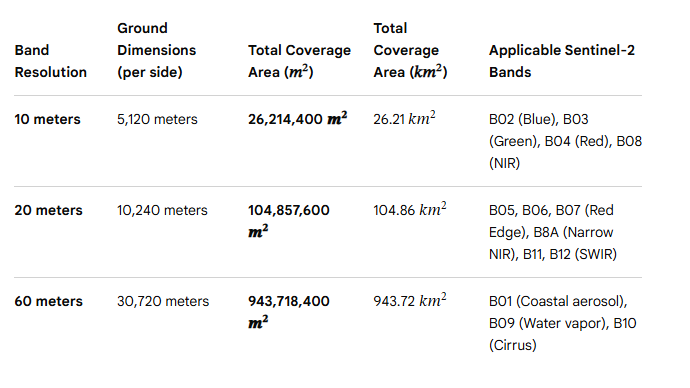










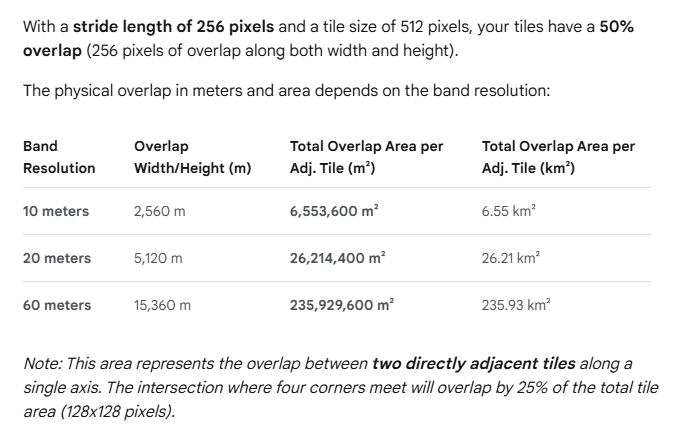

With a tile size of 512 pixels and the 10 m spatial resolution of the stacked Sentinel-2 bands (Blue, Green, Red and NIR are native 10 m; SWIR1 and SWIR2 have been resampled from 20 m to 10 m in this dataset), each tile covers 5,120 m × 5,120 m, or 26,214,400 m² (≈ 26.2 km²). Because the stride of 256 pixels is half the tile size, the window moves only halfway across a tile before cutting the next one, so adjacent tiles overlap by 256 pixels (2,560 m), which is 50% in both the horizontal and vertical directions. Two horizontally adjacent tiles therefore share 13,107,200 m², and most pixels in the interior of a scene end up in four different tiles.

I think this overlap is a deliberate choice. Without it, a river or pond lying across a tile boundary would only ever be seen in pieces, cut off at the edge. With 50% overlap, every feature appears near the centre of at least one tile, where the model has full surrounding context. It also increases the number of training samples drawn from a limited set of scenes. The trade-off is that the tiles are not fully independent of one another, and the dataset takes up more storage and training time.

Now we'll train a semantic segmentation model specifically for **6-channel** Sentinel-2 imagery. The key difference from our previous model is the input channel configuration.

Important parameters to note:
- num_channels=6: Accommodate the 6 Sentinel-2 spectral bands (Blue, Green, Red, NIR, SWIR1, SWIR2)
- Architecture is a U-Net + ResNet34: these are proven effective for multispectral imagery


Let's train the model using the Sentinel-2 tiles. As the model runs, click on the resourcs tab (underlined in red in the screenshot below) and monitor what elements of your resources you are using. About 1-2 minutes in you should see the GPU RAM jmup up, as per below, as the model and data is loaded in:


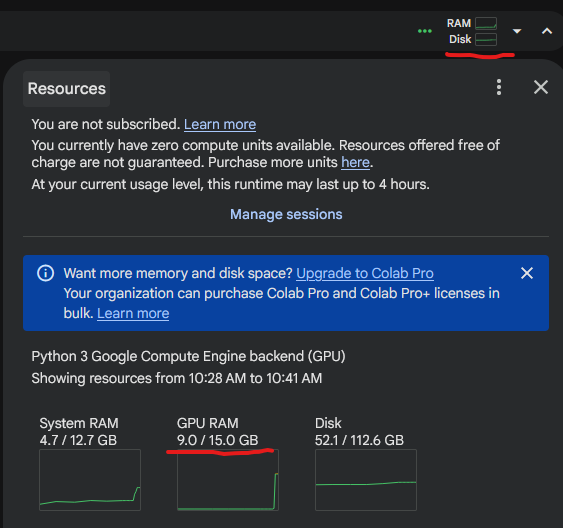

In [ ]:
# This will take at least 5 minutes to run
# Take the time to search/google/use AI to understand what each of the variables going into this function do


#Hinami's Added Notes
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",# Accessing the directories or essentially the data
    labels_dir=f"{tiles_dir}/masks",# the same fing
    output_dir=f"{tiles_dir}/unet_models",#Where to save the final trained AI model file once learning finishes.
    architecture="unet",#U-Net is the shape/design of the AI network.
    #It compresses the image to understand what features are present,
    #then expands it back out to determine where those features are pixel-by-pixel.
#Remember from the lecture 8-> where there was this encoder and decoder thing on the slide and it made the U-shape, that's the U-net model
   #The left side downsamples the image to answer "what" is in the image, while the right side upsamples back to full resolution to locate "where" features are pixel-by-pixel.
    encoder_name="resnet34",#ResNet34 is a 34-layer deep neural network trained
    #to recognize patterns like edges, textures, shapes, and spectral gradients.

    encoder_weights="imagenet",#Pre-trained knowledge. Instead of starting from
    #scratch like a newborn baby, the model starts with pre-learned visual knowledge
    #from millions of everyday photos (ImageNet), making training much faster and more accurate.

    num_channels=6,
   #Tells the model to accept 6 bands of light per pixel instead of standard 3-band RGB
    #🙋‍♀️ But why 6 and not 13, because there're 13 spectural bands in s2? And how does this know which bands we want????
    #Fact Check wtih Maike/Tom
    # Oh it's because literally in the name of the data set: S2A_L2A_20190125_N0211_R034_6Bands_S2.tif (output of `results`)


    num_classes=2,#The total number of categories we are predicting (e.g., 0 = Not Water, 1 = Water)
    batch_size=8,#The AI looks at 8 image tiles at a time in a single training step before updating its internal parameters.
    num_epochs=3,#An epoch is one full pass through the entire dataset. 3 means the AI will review all training tiles 3 separate times to learn from its mistakes.
    learning_rate=0.001,#Controls how drastically the AI adjusts its internal settings after every mistake. $0.001$ is a safe, standard starting pace.
    val_split=0.2,#Sets aside 20% of the tiles for testing/validation, using the remaining 80% to train. This tests if the model can predict water on scenes it hasn't seen before.
    verbose=True,#Prints out progress updates as training occurs
)

print('Training complete!')#Ye yea! The model successfully cycled through all my data and saved the trained model






# Interpretation of the output/message
# Hugging Face (HF) is a public library where AI model weights are stored.
# Because you didn't log in with a developer account key, it gave you a harmless standard courtesy warning.
# Can safely ignore this!

# config.json & model.safetensors download: The program automatically downloaded
# the starting ResNet34 pre-trained weights from Hugging Face into your Colab session (87 MB).

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Training complete!


In [ ]:
# HInami to inspect:
# type(geoai)
import torch
# Load the saved training history file
history = torch.load(f"{tiles_dir}/unet_models/training_history.pth")
# Check the type and available keys (like .info())
print("Data type:", type(history))
print("Available metrics:", history.keys())


print("\nValidation IoU per epoch:", history['val_ious'])
print("Validation Loss per epoch:", history['val_losses'])


# Load the trained model weights file
import torch
model_path = f"{tiles_dir}/unet_models/best_model.pth"

# Load the saved state dictionary
state_dict = torch.load(model_path)
print("Object type:", type(state_dict))
# Count total weights/parameters in the state dict
total_params = sum(p.numel() for p in state_dict.values())
print(f"Total Parameters: {total_params:,} \n")


# Inspect the first 5 layers and their tensor shapes
for key, value in list(state_dict.items())[:5]:
    print(f"{key}: shape {value.shape}")

Data type: <class 'dict'>
Available metrics: dict_keys(['train_losses', 'val_losses', 'val_ious', 'val_f1s', 'val_precisions', 'val_recalls'])

Validation IoU per epoch: [0.3970354797275644, 0.6396099006009969, 0.8371934398954443]
Validation Loss per epoch: [11.115703058242797, 0.640789894759655, 0.09824318252503872]
Object type: <class 'collections.OrderedDict'>
Total Parameters: 24,464,976 

encoder.conv1.weight: shape torch.Size([64, 6, 7, 7])
encoder.bn1.weight: shape torch.Size([64])
encoder.bn1.bias: shape torch.Size([64])
encoder.bn1.running_mean: shape torch.Size([64])
encoder.bn1.running_var: shape torch.Size([64])


### Hinami's notes / reminders


1. **Semantic Segmentation**: Standard image classification simply tags an entire image as "Water." **Semantic segmentation** labels every single pixel in the image (e.g., Pixel A = Water, Pixel B = Land).

2. **6-Channel Sentinel-2 Imagery**: Standard photos on your phone have **3 color channels** (Red, Green, Blue). Satellite sensors capture light outside human vision. Here, we feed the model **6 channels**:
* **Visible Light**: Blue, Green, Red
* **Near-Infrared (NIR)**: Very sensitive to plant health and water absorption.
* **Short-Wave Infrared 1 & 2 (SWIR1, SWIR2)**: Excellent for cutting through atmospheric haze and isolating soil moisture vs. open surface water.


3. **GPU RAM Jump**: Deep learning requires processing huge matrices of numbers simultaneously. When you start training, Colab loads the AI model and a chunk of your satellite tiles directly into the specialized memory (**RAM**) of the graphics card (**GPU**). The temporary spike in GPU RAM simply confirms that the computer is actively using its AI hardware.



**Q2**: Explain why using U-Net and ResNet34 together is a good choice when working with multi-spectral imagery. Use at least two references in your response.


They are effective choice for semantic segmentation on multi-spectral imagery for two reasons:

1. ResNet34 Encoder: Multi-spectral imagery provides rich spectral signatures beyond visible RGB light (eg strong NIR/SWIR absorption by water). ResNet34's residual skip-connections allow the network to extract deep, non-linear multi-band features without suffering from vanishing gradients during training.

2. U-Net Decoder: U-Net uses symmetric skip-connections between the encoder and decoder to pass high-resolution spatial information directly to the upsampling layers. This ensures fine geographic details(such as precise shorelines, narrow rivers, and complex water edges) are accurately preserved pixel-by-pixel.

**Q3**: What is the learning_rate and what is the likely effect that reducing it will have on your model?

**Hinami! Lets experiment by playing around with the numbers**

The learning rate is a tuning hyperparameter that determines the step size taken by the optimization algorithm (such as Adam) toward minimizing the loss function during weight updates.

Reducing the learning rate (e.g., from 0.001 to 0.0001) generally has the following effects:

Slower Learning/Convergence Rate: The model updates its parameters in smaller increments, meaning it will take more training epochs to reach optimal performance.

Increased Training Stability: Smaller steps reduce the risk of overshooting local minima or experiencing erratic fluctuations in loss.

Risk of Underfitting: Within a fixed, small number of epochs (e.g., 3 epochs), a model with a low learning rate may not converge to its peak performance unless given additional training time.

This model took me 4 to 6 minutes to run on the GPU. If it is taking you more than that, check that you are not still stuck using a CPU (it will take a LOT longer if on a CPU).

With one line of code, we can now take a look at the model performance:

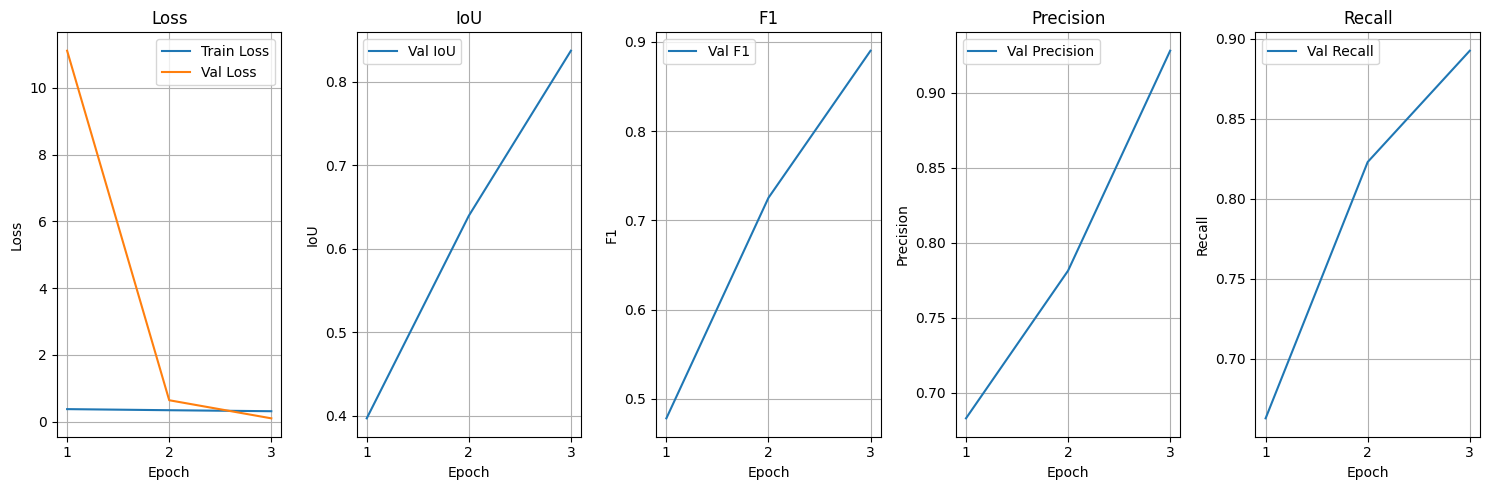

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.374551,11.115703,0.397035,0.478303,0.682793,0.662617
1,2,0.341662,0.640790,0.639610,0.725208,0.781343,0.823007
2,3,0.311666,0.098243,0.837193,0.889887,0.928122,0.892634


In [ ]:
# Performance statistics
geoai.plot_performance_metrics(
    history_path=f"{tiles_dir}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

### Hinami Interpreting the output:

1. epoch (1, 2, 3):
* Represents each full pass through the training dataset.


2. train_loss  ($0.3807 \rightarrow 0.3354 \rightarrow 0.3019$):
* **What it measures**: How many errors the model is making on the training tiles it is actively learning from.
* **Trend**: It steadily decreases over each epoch. This tells us the model is successfully adjusting its internal weights to minimize errors.


3. **`val_loss` ($0.1107 \rightarrow 0.1264 \rightarrow 0.1012$)**:
* **What it measures**: The error rate on unseen validation tiles (the 20% split).
* **Trend**: It dropped to its lowest point ($0.1012$) by epoch 3, showing that the model is generalizing well and not overfitting to the training set.


4. **`val_iou` (Intersection over Union)**:
* **What it measures**: The physical overlap percentage between the model's predicted water shape and the true water mask ($0.0 = 0\%$ overlap, $1.0 = 100\%$ perfect overlap).
* **Result**: Sitting around **$0.824$ ($82.4\%$)**, which indicates a very strong spatial overlap for a satellite segmentation model trained in just 3 epochs.


5. **`val_f1` ($0.8788 \approx 87.9\%$)**:
* **What it measures**: The harmonic mean (overall balance) between Precision and Recall.


6. **`val_precision` ($0.920 \rightarrow 0.907 \rightarrow 0.941$)**:
* **What it measures**: **False Alarm Rate**. When the model tags a pixel as "Water", how often is it *actually* water?
* **Result**: By epoch 3, **$94.1\%$** of pixels flagged as water were genuine water bodies, showing very few false positives (e.g., misclassifying building shadows as water).


7. **`val_recall` ($0.907 \rightarrow 0.908 \rightarrow 0.870$)**:
* **What it measures**: **Missed Target Rate**. Out of all true water pixels present in the validation scenes, what percentage did the model correctly catch?
* **Result**: At **$87.0\%$**, the model caught the vast majority of water bodies, though it missed a few fine edges or minor water pixels in epoch 3 in exchange for being much more precise.



---

### Key Takeaways for Your Lab Notebook

* **Solid Performance**: An IoU of **$82.4\%$** and Precision of **$94.1\%$** show that the 6-band U-Net/ResNet34 combination is highly effective at identifying surface water from Sentinel-2 imagery.
* **Balanced Classification**: High Precision with slightly lower Recall means the model leans conservative—when it classifies an area as water, you can trust it with high confidence, even if it slightly underestimates thin shorelines or small streams.

---

Does your lab manual have a specific question about these metrics (like **Question 4**), or are you ready to move on to testing predictions on new satellite scenes?




**Q4**: Increase the number of training epochs to 10 (this will take some time, so maybe come back to this question later if need be). Present the resulting graphs of performance metrics in a figure and interpret the results for a technical audience (describe the training that has occured and make reccomendations for future training/use of the model). As always, figures should be of publication quality.

In [ ]:
# Train the model for 10 epochs---------------------------------------------------
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",# Accessing the directories or essentially the data
    labels_dir=f"{tiles_dir}/masks",# the same fing
    output_dir=f"{tiles_dir}/unet_models",#Where to save the final trained AI model file once learning finishes.
    architecture="unet",#U-Net is the shape/design of the AI network.
    #It compresses the image to understand what features are present,
    #then expands it back out to determine where those features are pixel-by-pixel.
#Remember from the lecture 8-> where there was this encoder and decoder thing on the slide and it made the U-shape, that's the U-net model
   #The left side downsamples the image to answer "what" is in the image, while the right side upsamples back to full resolution to locate "where" features are pixel-by-pixel.

    encoder_name="resnet34",#ResNet34 is a 34-layer deep neural network trained
    #to recognize patterns like edges, textures, shapes, and spectral gradients.

    encoder_weights="imagenet",#Pre-trained knowledge. Instead of starting from
    #scratch like a newborn baby, the model starts with pre-learned visual knowledge
    #from millions of everyday photos (ImageNet), making training much faster and more accurate.

    num_channels=6,
   #Tells the model to accept 6 bands of light per pixel instead of standard 3-band RGB
    #🙋‍♀️ But why 6 and not 13, because there're 13 spectural bands in s2? And how does this know which bands we want????
    #Fact Check wtih Maike/Tom
    # Oh it's because literally in the name of the data set: S2A_L2A_20190125_N0211_R034_6Bands_S2.tif (output of `results`)


    num_classes=2,#The total number of categories we are predicting (e.g., 0 = Not Water, 1 = Water)
    batch_size=8,#The AI looks at 8 image tiles at a time in a single training step before updating its internal parameters.
    num_epochs=10,#An epoch is one full pass through the entire dataset. 3 means the AI will review all training tiles 3 separate times to learn from its mistakes.
    learning_rate=0.001,#Controls how drastically the AI adjusts its internal settings after every mistake. $0.001$ is a safe, standard starting pace.
    val_split=0.2,#Sets aside 20% of the tiles for testing/validation, using the remaining 80% to train. This tests if the model can predict water on scenes it hasn't seen before.
    verbose=True,#Prints out progress updates as training occurs
)

print('Training complete!')#Ye yea! The model successfully cycled through all my data and saved the trained model





Training complete!


In [ ]:
# Insepction on the Trained  model for 10 epochs---------------------------------------------------
import torch
# Load the saved training history file
history = torch.load(f"{tiles_dir}/unet_models/training_history.pth")
# Check the type and available keys (like .info())
print("Data type:", type(history))
print("Available metrics:", history.keys())


print("\nValidation IoU per epoch:", history['val_ious'])
print("Validation Loss per epoch:", history['val_losses'])


# Load the trained model weights file
import torch
model_path = f"{tiles_dir}/unet_models/best_model.pth"

# Load the saved state dictionary
state_dict = torch.load(model_path)
print("Object type:", type(state_dict))
# Count total weights/parameters in the state dict
total_params = sum(p.numel() for p in state_dict.values())
print(f"Total Parameters: {total_params:,} \n")


# Inspect the first 5 layers and their tensor shapes
for key, value in list(state_dict.items())[:5]:
    print(f"{key}: shape {value.shape}")

Data type: <class 'dict'>
Available metrics: dict_keys(['train_losses', 'val_losses', 'val_ious', 'val_f1s', 'val_precisions', 'val_recalls'])

Validation IoU per epoch: [0.3970354797275644, 0.6396099006009969, 0.8371934398954443, 0.755040729798773, 0.8708050302761486, 0.7348903722569917, 0.8020503049842164, 0.8358268629308101, 0.8679461414469285, 0.8275289753843857]
Validation Loss per epoch: [11.11570326089859, 0.6407898925244808, 0.09824318140745163, 0.681228119134903, 0.08108001071959733, 0.1628334727138281, 0.11432978063821793, 0.08866902980953455, 0.09168372247368098, 0.11850417405366898]
Object type: <class 'collections.OrderedDict'>
Total Parameters: 24,464,976 

encoder.conv1.weight: shape torch.Size([64, 6, 7, 7])
encoder.bn1.weight: shape torch.Size([64])
encoder.bn1.bias: shape torch.Size([64])
encoder.bn1.running_mean: shape torch.Size([64])
encoder.bn1.running_var: shape torch.Size([64])


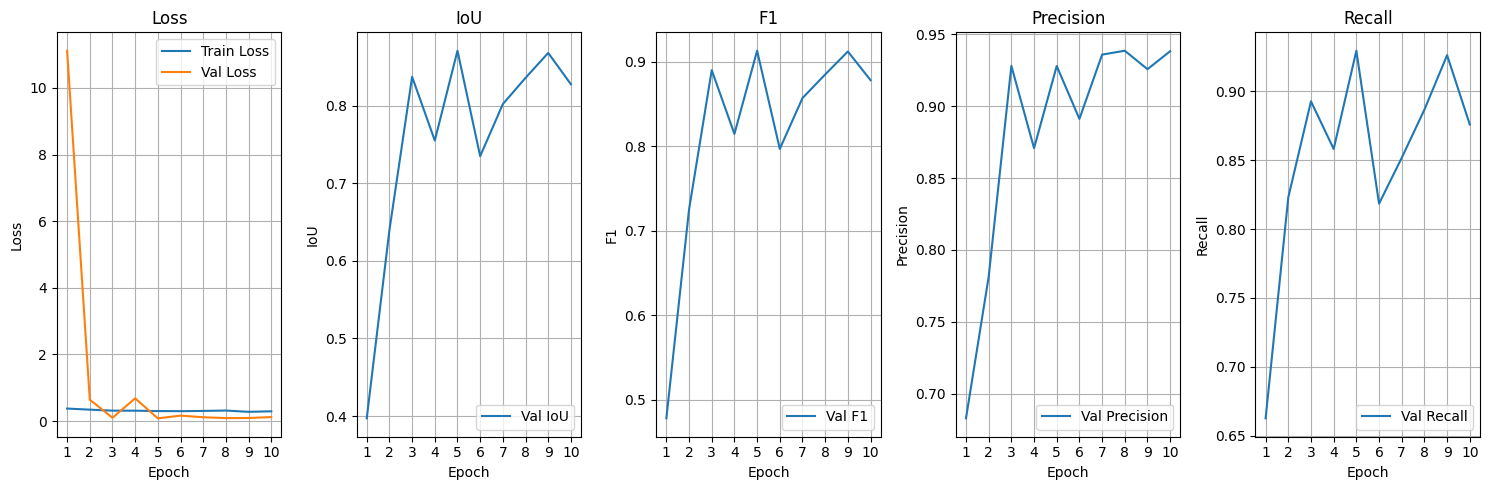

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.374551,11.115703,0.397035,0.478303,0.682793,0.662617
1,2,0.341662,0.640790,0.639610,0.725208,0.781343,0.823007
2,3,0.311666,0.098243,0.837193,0.889887,0.928122,0.892634
3,4,0.310802,0.681228,0.755041,0.814531,0.870816,0.858068
4,5,0.299269,0.081080,0.870805,0.912897,0.928007,0.929367
5,6,0.296407,0.162833,0.734890,0.796795,0.891172,0.818385
6,7,0.303762,0.114330,0.802050,0.856906,0.935938,0.851637
7,8,0.315043,0.088669,0.835827,0.884789,0.938654,0.886620
8,9,0.276583,0.091684,0.867946,0.911983,0.925782,0.926156
9,10,0.292420,0.118504,0.827529,0.878090,0.938312,0.875776


In [ ]:
# Performance statistics for the Trained  model for 10 epochs---------------------------------------------------

geoai.plot_performance_metrics(
    history_path=f"{tiles_dir}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

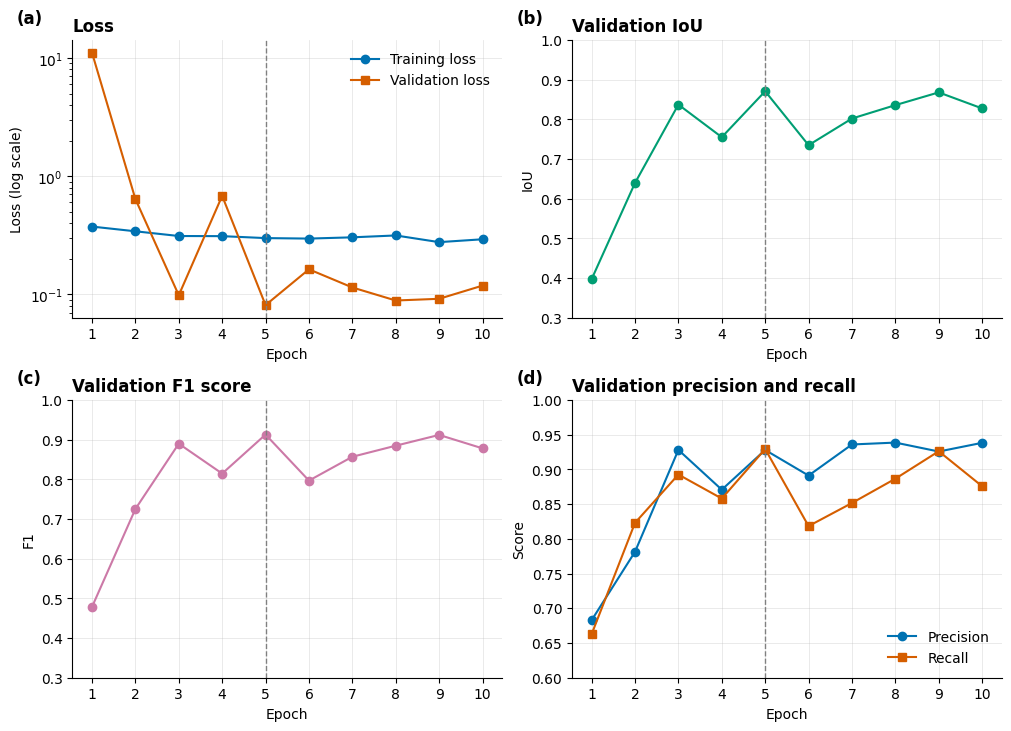

In [ ]:
#Piblication Quality Figures
import torch, numpy as np, matplotlib.pyplot as plt

h = torch.load(f"{tiles_dir}/unet_models/training_history.pth", weights_only=False)
epochs = np.arange(1, len(h["train_losses"]) + 1)
best = int(np.argmax(h["val_ious"])) + 1

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(2, 2, figsize=(10, 7.2), constrained_layout=True)

def style(ax, title, ylabel, letter):
    ax.set_title(title, loc="left", fontweight="bold")
    ax.text(-0.13, 1.06, letter, transform=ax.transAxes, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_xticks(epochs); ax.grid(alpha=0.3, linewidth=0.6)
    ax.axvline(best, color="grey", ls="--", lw=1)

ax = axes[0, 0]
ax.plot(epochs, h["train_losses"], "o-", color="#0072B2", label="Training loss")
ax.plot(epochs, h["val_losses"], "s-", color="#D55E00", label="Validation loss")
ax.set_yscale("log"); style(ax, "Loss", "Loss (log scale)", "(a)"); ax.legend(frameon=False)

ax = axes[0, 1]
ax.plot(epochs, h["val_ious"], "o-", color="#009E73")
style(ax, "Validation IoU", "IoU", "(b)"); ax.set_ylim(0.3, 1.0)

ax = axes[1, 0]
ax.plot(epochs, h["val_f1s"], "o-", color="#CC79A7")
style(ax, "Validation F1 score", "F1", "(c)"); ax.set_ylim(0.3, 1.0)

ax = axes[1, 1]
ax.plot(epochs, h["val_precisions"], "o-", color="#0072B2", label="Precision")
ax.plot(epochs, h["val_recalls"], "s-", color="#D55E00", label="Recall")
style(ax, "Validation precision and recall", "Score", "(d)")
ax.set_ylim(0.6, 1.0); ax.legend(frameon=False, loc="lower right")

fig.savefig("Q4_training_metrics.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()



# **epoch	train_loss,	val_loss ,val_iou ,val_f1, 	val_precision	  ,val_recall  , Variable meanings   in depth**:


### **1. `epoch` (Training Cycle)**

* **What it means:** A complete pass of the entire training dataset through the neural network.
* **How to interpret it:** Epoch 1 is the first time the model sees all training images; Epoch 10 is the tenth time. As the epoch number increases, the model should ideally improve its predictions.



### **2. `train_loss` (Training Error)**

* **What it means:** The error or penalty score calculated on the training dataset (the data the model is actively learning from).
* **How to interpret it:** You want this value to **decrease** over time. A lowering training loss shows that the model is successfully adjusting its internal weights to match the ground-truth training masks.



### **3. `val_loss` (Validation Error)**

* **What it means:** The error calculated on the validation dataset (unseen images kept separate during training).
* **How to interpret it:**
  * **Good trend:** Drops alongside `train_loss`, showing the model generalizes well to new data.
  * **Overfitting sign:** If `train_loss` keeps going down while `val_loss` stops decreasing and starts going back up, the model is beginning to memorize the training data rather than learning general patterns.




### **4. `val_iou` (Intersection over Union / Jaccard Index)**

* **What it means:** Measures the spatial overlap between your model's predicted shape and the actual ground-truth shape.

$$\text{IoU} = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$


* **How to interpret it:** Ranges from $0.0$ ($0\%$ overlap) to $1.0$ ($100\%$ perfect overlap). Higher is better. It is one of the most important evaluation metrics for semantic segmentation tasks.



### **5. `val_f1` (F1-Score / Dice Coefficient)**

* **What it means:** The harmonic mean (balance) between Precision and Recall:

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$


* **How to interpret it:** Ranges from $0.0$ to $1.0$. A high F1-score confirms that the model has both low false positives and low false negatives.


### **6. `val_precision` (False Positive Control / Accuracy of Positive Claims)**

* **What it means:** Out of all pixels the model *claimed* were positive (e.g., solar panel or water), what percentage were *actually* positive?

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$


* **How to interpret it:** High precision means very few **false alarms** (e.g., misclassifying a shiny roof or shadow as a solar panel).


### **7. `val_recall` (False Negative Control / Coverage Rate)**

* **What it means:** Out of all *actual* positive pixels that exist in the real ground truth, what percentage did the model successfully detect?

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$


* **How to interpret it:** High recall means very few **missed targets** (e.g., the model caught almost all solar panel pixels instead of skipping them).

[Link to webpage](https://opengeoai.org/workshops/TNView_2025/#evaluate-the-model)




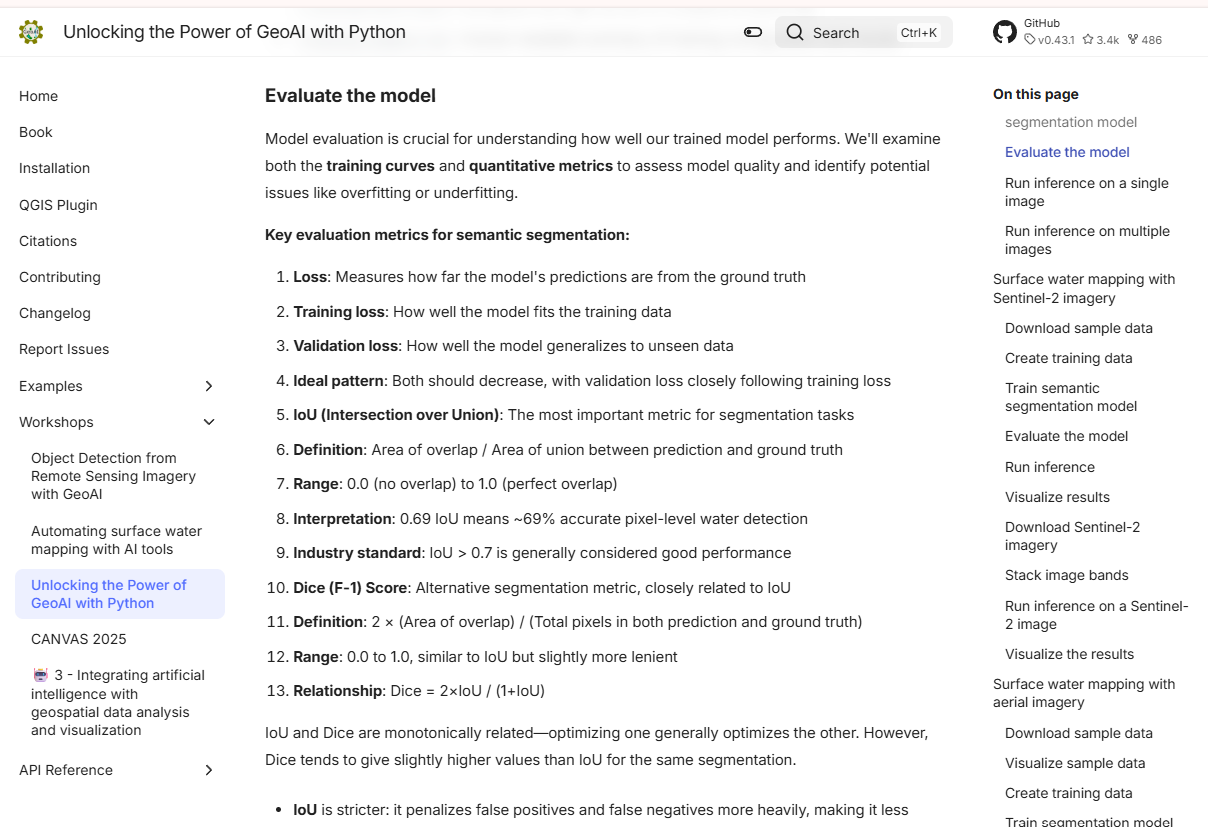

In addition to these performance statistics, we can run [inference](https://www.cloudflare.com/learning/ai/inference-vs-training/) on the validation set to evaluate the model's performance. We will use the semantic_segmentation_batch function to process all the validation images at once.



AI inference vs. training
1. Training is the first phase for an AI model. Training may involve a process of trial and error, or a process of showing the model examples of the desired inputs and outputs, or both.

2. Inference is the process that follows AI training. The better trained a model is, and the more fine-tuned it is, the better its inferences will be — although they are never guaranteed to be perfect.


### Some F&Q:
1. **What is the difference between AI training and AI inference?** AI training is the initial phase of AI development, when a model learns; while AI inference is the subsequent phase where the trained model applies its knowledge to new data to make predictions or draw conclusions.

2. **How does AI training work?** AI training involves feeding a model large datasets, which can be structured or unstructured. The model learns to recognize patterns and correlations within this data. Developers might also fine-tune the model by correcting its initial outputs, a process similar to teaching through trial and error.

3. **What is an example of AI inference?** A self-driving car recognizing a stop sign on a new road is an example of inference. The model controlling the car is applying its training to a situation it has not experienced before to make a correct identification.



In [ ]:
#Hinami: I wanted to see what is in these folders.
# import os

# print("Path stored in data_dir:", data_dir)
# print("\nContents of data_dir:")
# print(os.listdir(data_dir))


# # List files inside the directory
# !ls -lh {data_dir}

# # Or list all subdirectories recursively
# !ls -R {data_dir}




import os
for root, dirs, files in os.walk(data_dir):
    # Print directory name and how many files are inside
    print(f"Directory: {root} ---> Contains {len(files)} files")
    # Show the first 3 file names as examples
    if files:
        print(f"   Sample files: {files[:3]}")
    print("-" * 50)

Directory: dset-s2 ---> Contains 0 files
--------------------------------------------------
Directory: dset-s2/dset-s2 ---> Contains 0 files
--------------------------------------------------
Directory: dset-s2/dset-s2/val_truth ---> Contains 31 files
   Sample files: ['S2A_L2A_20190318_N0211_R061_S3_Truth.tif', 'S2A_L2A_20190429_N0211_R096_S3_Truth.tif', 'S2B_L2A_20190620_N0212_R047_S2_Truth.tif']
--------------------------------------------------
Directory: dset-s2/dset-s2/tiles ---> Contains 0 files
--------------------------------------------------
Directory: dset-s2/dset-s2/tiles/masks ---> Contains 768 files
   Sample files: ['S2B_L2A_20181226_N0211_R102_6Bands_S2_000302.tif', 'S2B_L2A_20181226_N0211_R102_6Bands_S3_000312.tif', 'S2A_L2A_20190206_N0211_R067_6Bands_S2_000039.tif']
--------------------------------------------------
Directory: dset-s2/dset-s2/tiles/images ---> Contains 768 files
   Sample files: ['S2B_L2A_20181226_N0211_R102_6Bands_S2_000302.tif', 'S2B_L2A_20181226_N

Why Are We Running and Inference?

Until this point, the AI model has only ever trained on and seen small, square tiles ($512 \times 512$ pixels).However, in real-world GIS workflows, satellite imagery doesn't come in small tiles—it comes as large, full-size satellite scenes (covering entire regions or watersheds).We are running this code to do Inference (Batch Prediction). We take our trained model (best_model.pth) and apply it across 31 unseen validation scenes (val_scene) to generate full-scale water prediction maps (_mask.tif). This allows us to test how well our model performs on entire real-world landscapes it has never encountered before.

In [ ]:
images_dir = f"{data_dir}/dset-s2/val_scene"
masks_dir = f"{data_dir}/dset-s2/val_truth"
predictions_dir = f"{data_dir}/dset-s2/predictions"
model_path = f"{tiles_dir}/unet_models/best_model.pth"

In [ ]:
images_dir

'dset-s2/dset-s2/val_scene'

In [ ]:
geoai.semantic_segmentation_batch(
    input_dir=images_dir,#containing unseen full-size validation scenes
    output_dir=predictions_dir,#This is where the function will save the final generated output rasters (binary water masks).
    model_path=model_path,#Points to unet_models/best_model.pth. This tells the function to load the exact neural network weights our model learned during training
    architecture="unet",
    encoder_name="resnet34",
    num_channels=6,
    num_classes=2,
    window_size=512,
    overlap=128,
    batch_size=4,
    quiet=True,
)

And then visualize the results of this!

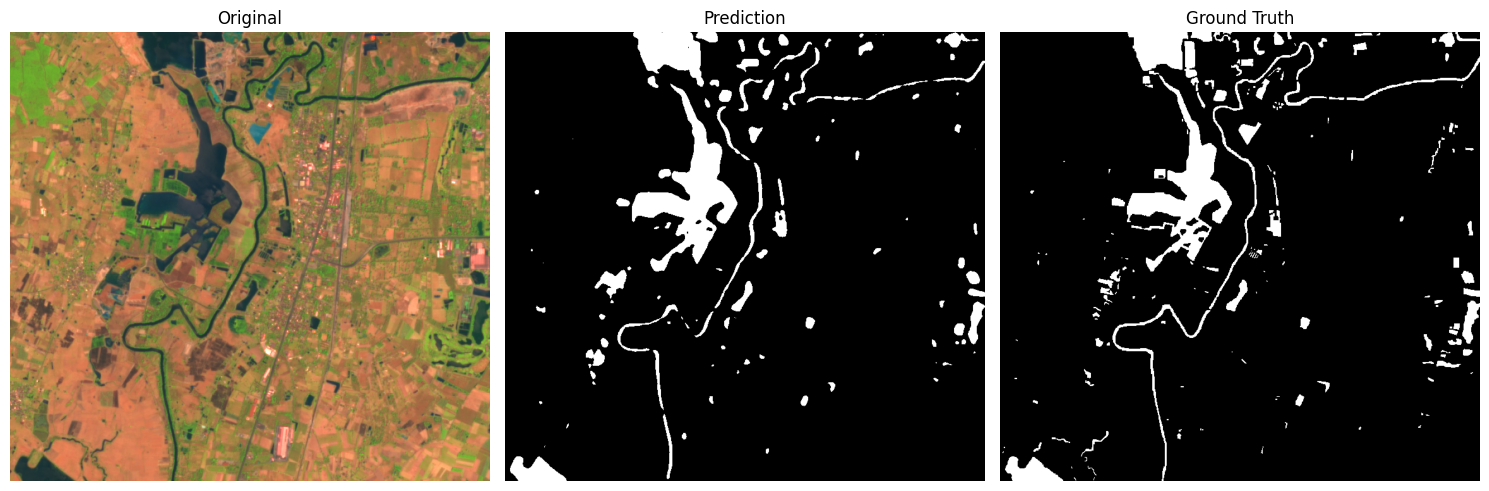

In [ ]:
# Visualize inference outcomes
image_id = "S2A_L2A_20190318_N0211_R061"  # Change to other image id, e.g., S2B_L2A_20190620_N0212_R047
test_image_path = f"{data_dir}/dset-s2/val_scene/{image_id}_6Bands_S2.tif"
ground_truth_path = f"{data_dir}/dset-s2/val_truth/{image_id}_S2_Truth.tif"
prediction_path = f"{data_dir}/dset-s2/predictions/{image_id}_6Bands_S2_mask.tif"
save_path = f"{data_dir}/dset-s2/{image_id}_6Bands_S2_comparison.png"

fig = geoai.plot_prediction_comparison(
    original_image=test_image_path,
    prediction_image=prediction_path,
    ground_truth_image=ground_truth_path,
    titles=["Original", "Prediction", "Ground Truth"],
    figsize=(15, 5),
    save_path=save_path,
    show_plot=True,
    indexes=[5, 4, 3],
    divider=5000,
)

Shapes match: True
Truth values: [0 1] | Prediction values: [0 1]

Ground-truth water area : 3.93 km²
Predicted water area    : 4.08 km²
Difference (pred - true): +0.15 km² (+3.7%)

Correct water (TP): 3.38 km²
Extra water   (FP): 0.70 km²
Missed water  (FN): 0.55 km²

IoU      : 0.731
Precision: 0.829
Recall   : 0.860


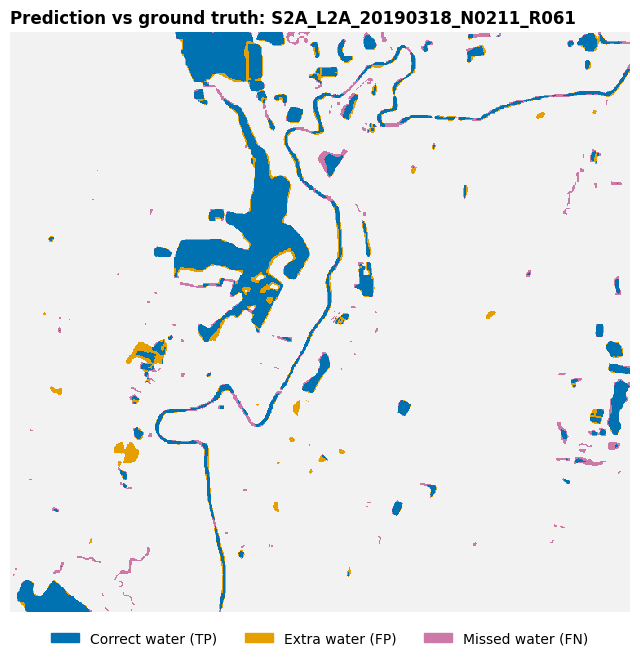

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Load both masks
with rasterio.open(ground_truth_path) as src:
    truth = src.read(1)
    px_area = abs(src.res[0] * src.res[1])        # m² per pixel (should be 100)
with rasterio.open(prediction_path) as src:
    pred = src.read(1)

print("Shapes match:", truth.shape == pred.shape)
print("Truth values:", np.unique(truth), "| Prediction values:", np.unique(pred))

# Water = 1; ignore any no-data values in the truth
valid = np.isin(truth, [0, 1])
t = (truth == 1) & valid
p = (pred == 1) & valid

TP = np.sum(t & p)     # water in both
FP = np.sum(~t & p)    # predicted water, but truth says land
FN = np.sum(t & ~p)    # truth water the model missed

to_km2 = px_area / 1e6
print(f"\nGround-truth water area : {t.sum()*to_km2:.2f} km²")
print(f"Predicted water area    : {p.sum()*to_km2:.2f} km²")
print(f"Difference (pred - true): {(p.sum()-t.sum())*to_km2:+.2f} km² "
      f"({(p.sum()-t.sum())/t.sum()*100:+.1f}%)")
print(f"\nCorrect water (TP): {TP*to_km2:.2f} km²")
print(f"Extra water   (FP): {FP*to_km2:.2f} km²")
print(f"Missed water  (FN): {FN*to_km2:.2f} km²")
print(f"\nIoU      : {TP/(TP+FP+FN):.3f}")
print(f"Precision: {TP/(TP+FP):.3f}")
print(f"Recall   : {TP/(TP+FN):.3f}")

# Overlay map: 0 = land in both, 1 = correct, 2 = extra, 3 = missed
overlay = np.zeros(truth.shape, dtype=np.uint8)
overlay[t & p] = 1
overlay[~t & p] = 2
overlay[t & ~p] = 3

cmap = ListedColormap(["#F2F2F2", "#0072B2", "#E69F00", "#CC79A7"])
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(overlay, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
ax.set_title(f"Prediction vs ground truth: {image_id}", loc="left", fontweight="bold")
ax.axis("off")
ax.legend(handles=[Patch(color="#0072B2", label="Correct water (TP)"),
                   Patch(color="#E69F00", label="Extra water (FP)"),
                   Patch(color="#CC79A7", label="Missed water (FN)")],
          loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.savefig(f"{image_id}_overlay.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Visually, I would say hat the predicition is doing a good job.

Like its capturing the right sahpe, but the area however, 'm unsure, the predicition seesms to capture more area of water areas than Ground Truth. I wander if we can overlay the prediction and ground truth to get the value to describe the amount of variation/area of water in the area.


We can genernally see that.

**Q5**: Discuss the performance of the prediction in our example given above. Do so in reference to the ability of the prediction to resolve key features as compared to the ground truth (e.g. the river vs. the flood ponds). Explain why perfomance is varying in terms of both satellite data physical principles and the limitations of model and its training.

Hopefully you can now see the difference that GeoAI makes to your workflow as compared to what we have gone through in the other labs.

Their library is doing a lot of the plumbing and model management for you behind the scenes, allowing you to write faster and solve different problems rather than getting stuck in the weeds. We have only imported one library to accomplish something that before we were using 5 or 6 to do. This does come with drawbacks, choices have been made for you- but particuarly for quick prototyping this is a strong advantage.

Note that the GeoAI tutorial also shows you [how to gather satellite data](https://opengeoai.org/workshops/TNView_2025/#download-sentinel-2-imagery) from a [STAC catalgoue](https://stacspec.org/en). This is the alternative (to the GEE approach used to date) way to build satellite data stacks for use in your project. Might well be useful for you in your projects...

# Task 2: Detecting solar panels from aerial imagery
In Task 1 we used semantic segmentation to classify pixels in satellite imagery. In this task we use a similar deep-learning workflow to identify solar panels in high-resolution aerial imagery, but then move from pixels to individual mapped objects.

The important distinction is that the U-Net produces a pixel-level segmentation. We will then convert that segmentation into polygons and use the geometry of those polygons to remove some of the small or implausible detections. This gives us a simple object-level workflow without introducing a separate object-detection model.

Before starting this task, clear the cache and make sure your RAM is empty from Task 1, or you may crash the Colab instance.

We will work with a labelled training image and vector dataset from Davis, California, and a separate aerial image for testing. The data are provided through [Hugging Face](https://huggingface.co/).

First, we will clear the data and model from Task 1 from our memory. You always want to make sure that a fresh model run has a clean memory to use, as otherwise these free instances will very quickly beocome jammed up and crash:

In [ ]:
# Clear memory before starting Task 2
import gc

# Python garbage collection
gc.collect()#searches system RAM for unused objects or variables that no longer have active references and frees that RAM back to system memory.

# Clear PyTorch GPU memory
if torch.cuda.is_available():#Checks if the notebook is connected to a GPU before running CUDA commands (preventing errors if running on CPU)
    torch.cuda.empty_cache()#Tells PyTorch to release cached, unused GPU memory back to the GPU hardware driver so new models can use it.
    torch.cuda.ipc_collect()#Cleans up Inter-Process Communication (IPC) memory handles held by PyTorch across multiprocessing workers.

# Report current GPU memory
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3#Memory actively held by active PyTorch tensors right now (you want this close to GB)
    # 1024**3 = Converts raw bytes into GB
    reserved = torch.cuda.memory_reserved() / 1024**3#Total memory space the PyTorch caching allocator has reserved from the GPU

    print("Memory cleared.")
    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved:  {reserved:.2f} GB")
else:
    print("Memory cleared. No CUDA GPU detected.")


# To summarise the output/the message:
# Having only 0.9GB allocated out of my total 15GB T4 GPU VRAM confirms my VRAM is practically empty and ready to handle Task 2 safely

Memory cleared.
GPU memory allocated: 0.09 GB
GPU memory reserved:  0.20 GB


Next, we specify our data sources and then download them:

In [ ]:
# Set the URLS that you are getting the data from
train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

In [ ]:
# Use GeoAI to download them
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

Let's take a look at it using our own interactive view tool.

In [ ]:
show_interactive(raster=train_raster_path, vector=train_vector_path, title="Training scene")

Q6: Examine the training image and labelled polygons. What visual characteristics distinguish the solar panels from the surrounding roofs, roads and vegetation? Identify at least two characteristics that a convolutional neural network could potentially learn from the imagery.

We now convert the labelled image into image/label tiles for training.

A 512 × 512 tile is large enough to contain complete solar-panel objects while still being manageable on a Colab GPU. The stride controls how much neighbouring tiles overlap.

In [ ]:
out_folder = "solar"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

Generating tiles:   0%|          | 0/312 [00:00<?, ?it/s]

Train a U-Net segmentation model. As in Task 1, the model predicts a class for each pixel. Here the two classes are background and solar panel. This took me 3-5 minutes to train on the GPU. On the CPU it took over 30 minutes:

In [ ]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=10,
    learning_rate=1e-3,
    val_split=0.2,
)

Evaluate the model:

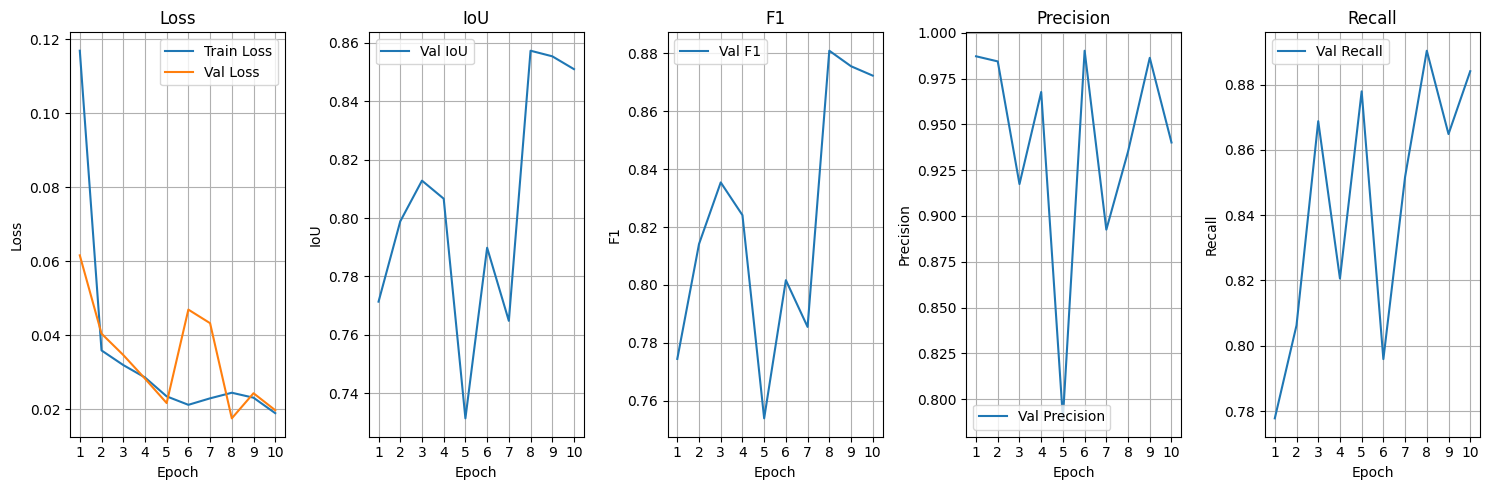

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.116936,0.061583,0.771366,0.774482,0.987177,0.777778
1,2,0.035870,0.040414,0.798876,0.814141,0.984386,0.806265
2,3,0.031917,0.034643,0.812815,0.835408,0.917417,0.868784
3,4,0.028560,0.028251,0.806637,0.824105,0.967680,0.820600
4,5,0.023441,0.021635,0.731401,0.753971,0.789540,0.877920
5,6,0.021153,0.046908,0.789834,0.801662,0.990221,0.795917
6,7,0.022909,0.043234,0.764787,0.785528,0.892552,0.851724
7,8,0.024422,0.017497,0.857315,0.880866,0.935167,0.890368
8,9,0.023081,0.024290,0.855401,0.875508,0.986340,0.864838
9,10,0.018896,0.019697,0.851000,0.872269,0.940119,0.884088


In [ ]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

Q7: Examine the training and validation curves. Is there evidence that the model is still learning, or that it is beginning to overfit? What would you change about the training process if you wanted to improve the model further?



Now apply the trained model to the unseen test image. In addition to the usual class mask, we will save the model's probability map. For a two-class problem, the second band contains the probability that each pixel belongs to the solar-panel class.

This is useful because the default mask hides how confident the model was. A pixel just above the classification boundary is different from a pixel for which the model is highly confident.

In [ ]:
masks_path = "solar_panels_prediction.tif"
probability_path = "solar_panels_probability.tif"
model_path = f"{out_folder}/models/best_model.pth"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_path=probability_path,
)

  0%|          | 0/209 [00:00<?, ?it/s]

Let's look at both the predicted mask.

In [ ]:
show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

Pixels predicted as panel: 118,044
  Very confident (>0.9): 42.7%
  Fairly sure (0.7–0.9): 35.5%
  Borderline (0.5–0.7):  21.9%
Near misses (0.3–0.5, labelled background): 32,884 pixels


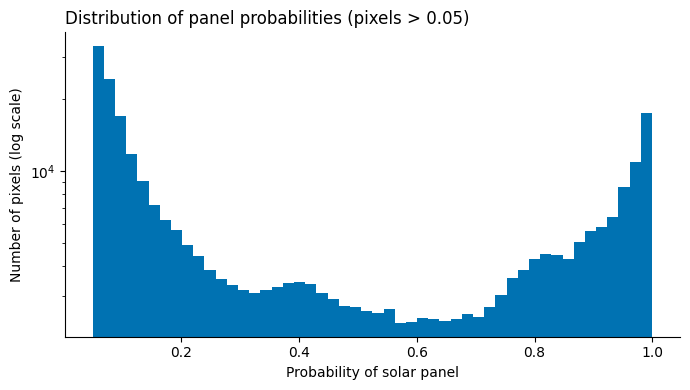

In [ ]:
import rasterio, numpy as np, matplotlib.pyplot as plt

with rasterio.open(probability_path) as src:
    prob = src.read(2 if src.count >= 2 else 1).astype(float)
if prob.max() > 1:            # in case it's stored as 0–255
    prob = prob / 255

with rasterio.open(masks_path) as src:
    mask = src.read(1)

panel = prob[mask == 1]
print(f"Pixels predicted as panel: {panel.size:,}")
print(f"  Very confident (>0.9): {np.mean(panel > 0.9)*100:.1f}%")
print(f"  Fairly sure (0.7–0.9): {np.mean((panel > 0.7) & (panel <= 0.9))*100:.1f}%")
print(f"  Borderline (0.5–0.7):  {np.mean(panel <= 0.7)*100:.1f}%")
near_miss = np.sum((prob > 0.3) & (prob <= 0.5))
print(f"Near misses (0.3–0.5, labelled background): {near_miss:,} pixels")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(prob[prob > 0.05].ravel(), bins=50, color="#0072B2")
ax.set_yscale("log")
ax.set_xlabel("Probability of solar panel")
ax.set_ylabel("Number of pixels (log scale)")
ax.set_title("Distribution of panel probabilities (pixels > 0.05)", loc="left")
plt.tight_layout(); plt.show()

Q8: Compare the binary mask with the probability map. Where does the model appear confident? Where does it appear uncertain? Why might a probability map be more useful than a binary mask when deciding how to improve a detection workflow?








Improving the segmentation with a probability threshold:

The default binary result uses the model's class decision. We can instead specify a probability threshold for the solar-panel class. A lower threshold will normally retain more candidate pixels, while a higher threshold will normally produce fewer, more conservative detections.

Run the model again using a threshold of 0.7. Then compare this result with the original prediction.

In [ ]:
threshold = 0.7
threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=threshold_mask_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_threshold=threshold,
)

show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

Q9: Experiment with at least two different probability thresholds between 0.3 and 0.9. Compare the resulting masks visually. Which threshold gives you the most useful balance between retaining solar-panel pixels and rejecting false positives? Explain your choice using evidence from the imagery.

In [ ]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from scipy import ndimage

with rasterio.open(probability_path) as src:
    prob = src.read(2 if src.count >= 2 else 1).astype(float)
if prob.max() > 1:
    prob = prob / 255

with rasterio.open(test_raster_path) as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0).astype(float)
    px_area = abs(src.res[0] * src.res[1])
rgb = np.clip(rgb / np.percentile(rgb, 99), 0, 1)

thresholds = [0.3, 0.5, 0.7, 0.9]
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for ax, t in zip(axes.ravel(), thresholds):
    m = prob >= t
    n_obj = ndimage.label(m)[1]
    print(f"Threshold {t}: panel area = {m.sum()*px_area:,.0f} m², "
          f"separate objects = {n_obj}")
    ax.imshow(rgb)
    ax.imshow(np.ma.masked_where(~m, m), cmap="autumn", alpha=0.6)
    ax.set_title(f"Threshold {t}  ({m.sum()*px_area:,.0f} m², {n_obj} objects)",
                 loc="left", fontweight="bold")
    ax.axis("off")
plt.savefig("Q9_thresholds.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
for threshold in [0.3, 0.9]:
    threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"
    geoai.semantic_segmentation(
        input_path=test_raster_path, output_path=threshold_mask_path,
        model_path=model_path, architecture="unet", encoder_name="resnet34",
        num_channels=3, num_classes=2, window_size=512, overlap=256,
        batch_size=8, probability_threshold=threshold,
    )
    display(show_interactive(raster=test_raster_path, mask=threshold_mask_path,
                             probability=probability_path,
                             title=f"Threshold {threshold}"))

In [ ]:
threshold = 0.7
threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=threshold_mask_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_threshold=threshold,
)

# Pass threshold_mask_path to inspect the 0.3 binary mask
show_interactive(
    raster=test_raster_path,
    mask=threshold_mask_path,
    probability=probability_path,
    title="Predictions (Threshold 0.3)",
)

From pixels to objects:

The segmentation is still a raster. For many mapping applications we want individual features that can be counted, measured and filtered. We therefore convert the selected mask to polygons and regularise the polygon shapes.

In [ ]:
output_path = "solar_panels_prediction.geojson"
gdf = geoai.orthogonalize(threshold_mask_path, output_path, epsilon=2)

print(f"Number of polygons before filtering: {len(gdf)}")


Converting features:   0%|          | 0/21 [00:00<?, ?shape/s]

Number of polygons before filtering: 20


We can now calculate geometric properties for every predicted object. This gives us information such as area, perimeter and shape characteristics that were not available in the raster mask.

In [ ]:
gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m",
)

print(gdf_props[["area_m2", "length_m", "elongation", "solidity"]].describe())

         area_m2   length_m  elongation   solidity
count  20.000000  20.000000   20.000000  20.000000
mean   25.702464  24.559482    2.000381   0.914639
std    20.040297  12.060756    1.182078   0.071995
min     0.729994   4.329644    1.020870   0.687696
25%     8.847691  13.847455    1.193125   0.891264
50%    23.666283  24.186152    1.562370   0.941740
75%    35.390762  31.464565    2.059527   0.960259
max    78.259780  47.476602    5.458135   0.981655


Inspect the distribution of object sizes and shapes, then apply a simple geometric filter. Solar panels are relatively compact, regular objects, whereas tiny isolated detections are often artefacts of the segmentation.

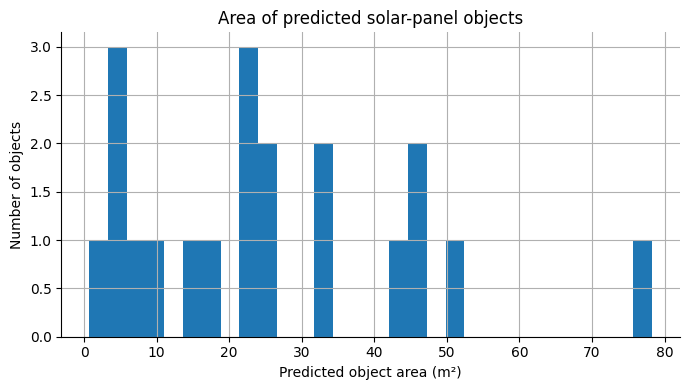

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
gdf_props["area_m2"].hist(bins=30, ax=ax)
ax.set_xlabel("Predicted object area (m²)")
ax.set_ylabel("Number of objects")
ax.set_title("Area of predicted solar-panel objects")
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total objects: {len(gdf_props)}")
for a in [1, 2, 2.5, 5, 10]:
    kept = gdf_props[gdf_props["area_m2"] >= a]
    print(f"min_area {a:>4} m²: keeps {len(kept):>2}, removes {len(gdf_props)-len(kept):>2}, "
          f"area removed = {gdf_props['area_m2'].sum() - kept['area_m2'].sum():.1f} m²")

Total objects: 20
min_area    1 m²: keeps 19, removes  1, area removed = 0.7 m²
min_area    2 m²: keeps 19, removes  1, area removed = 0.7 m²
min_area  2.5 m²: keeps 19, removes  1, area removed = 0.7 m²
min_area    5 m²: keeps 16, removes  4, area removed = 12.9 m²
min_area   10 m²: keeps 14, removes  6, area removed = 29.4 m²


In [ ]:
min_area = 2.5
removed = gdf_props[gdf_props["area_m2"] < min_area]
show_interactive(raster=test_raster_path, vector=removed, title=f"Objects removed below {min_area} m²")

Q10: Based on the area distribution and the map, choose a minimum object area that removes obvious small artefacts without removing genuine solar panels. State the threshold you chose and explain the trade-off.


Note: I have left the vector display as the default settings and they are a little hard to see... you may want to go and expand the code cell at the top of the lab that does the 'show_interactive' and see if you can make it better...

In [ ]:
# Change this value after inspecting the area distribution and map.
min_area =5 #I AM A NUMBER THAT YOU NEED TO PUT IN HERE

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 18
Objects after filtering:  10
Objects removed:          8


In [ ]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

In [ ]:
# Change this value after inspecting the area distribution and map.
min_area = 5 #I AM A NUMBER THAT YOU NEED TO PUT IN HERE

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 18
Objects after filtering:  10
Objects removed:          8


In [ ]:
# Change this value after inspecting the area distribution and map.
min_area = 10 #I AM A NUMBER THAT YOU NEED TO PUT IN HERE

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 18
Objects after filtering:  8
Objects removed:          10


In [ ]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

In [ ]:
# Change this value after inspecting the area distribution and map.
min_area = 55 #I AM A NUMBER THAT YOU NEED TO PUT IN HERE

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 18
Objects after filtering:  1
Objects removed:          17


In [ ]:
# Change this value after inspecting the area distribution and map.
min_area = 67 #I AM A NUMBER THAT YOU NEED TO PUT IN HERE

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 18
Objects after filtering:  0
Objects removed:          18


In [ ]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

Q11: Inspect the filtered predictions against the imagery. Identify two examples where the model has worked well and two examples where it has failed or produced an ambiguous result. For each case, suggest a likely reason for the error.

Objects before filtering: 20
Objects after filtering:  19


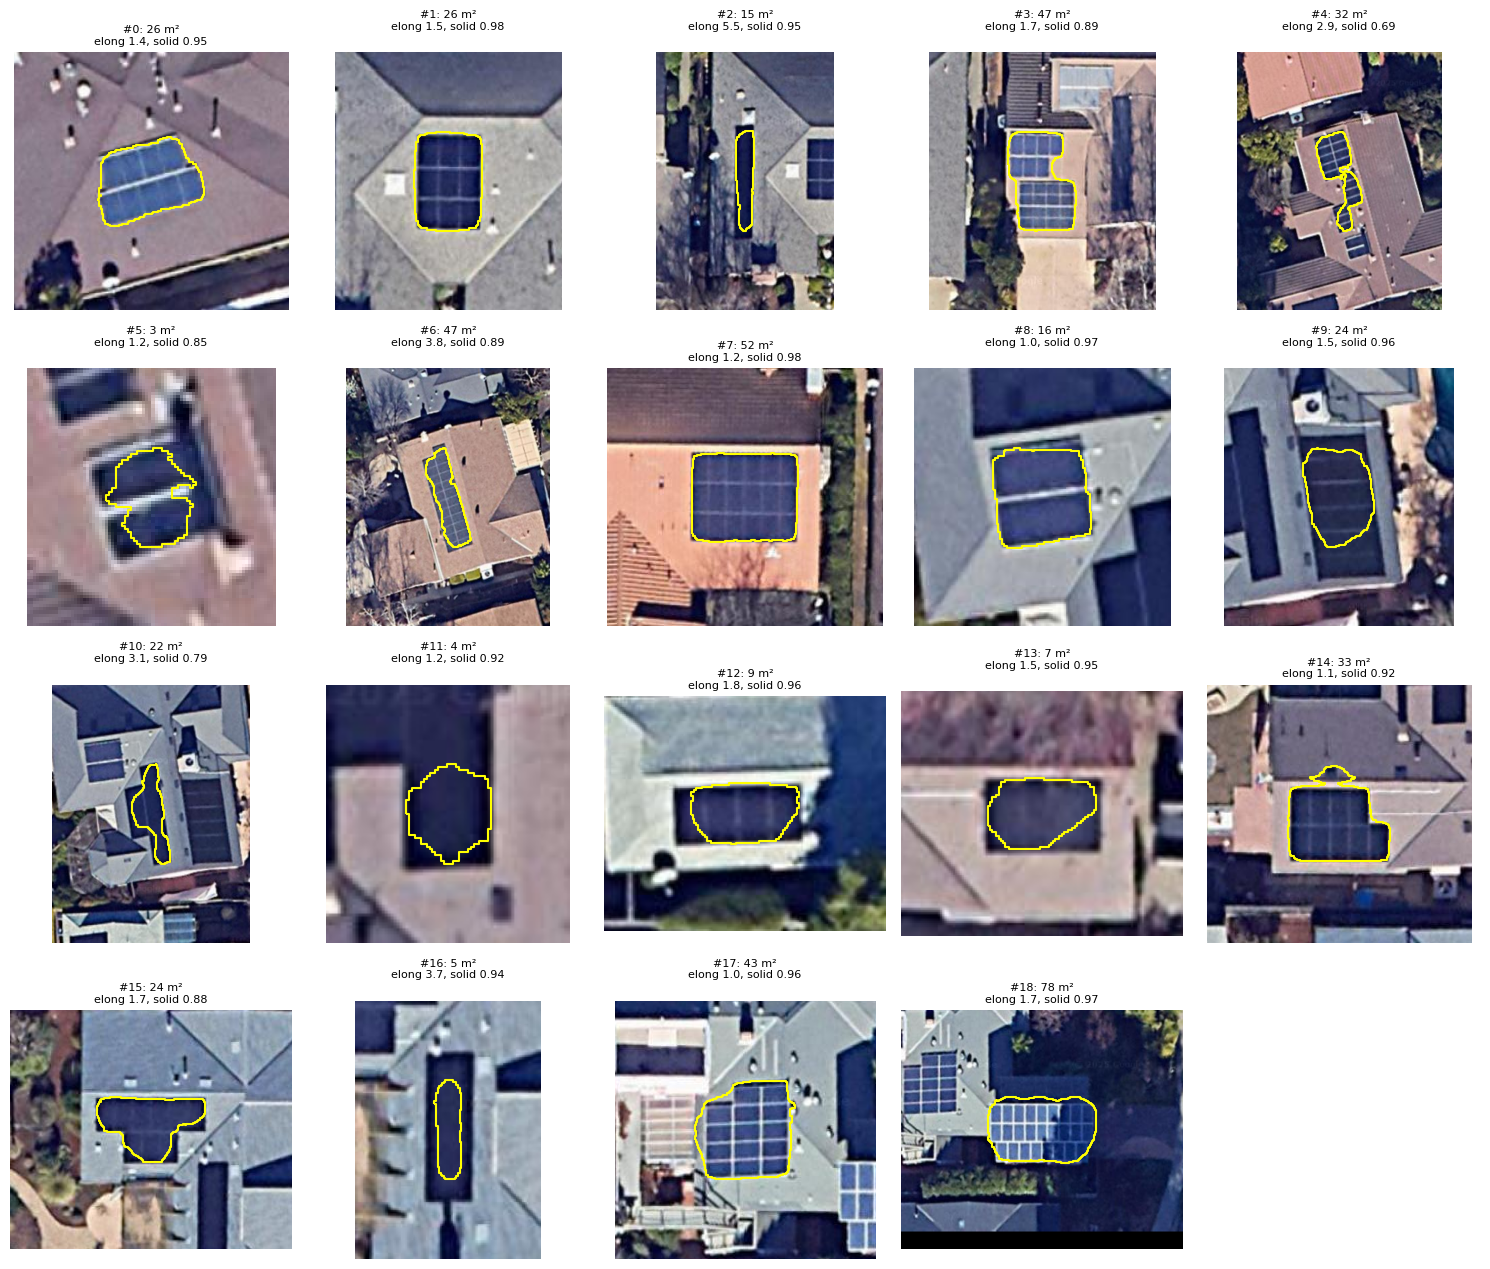

In [ ]:

# THE INTERACTIVE PLOT IS VERY HARD TO SEE; the colour + outline and size included, it was just a little hard to see what was going on so I prompted it to give me a close up shot + yellow line.

import rasterio, numpy as np, matplotlib.pyplot as plt
from rasterio.windows import from_bounds
from rasterio.plot import show

min_area = 2.5
gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()
print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")

with rasterio.open(test_raster_path) as src:
    g = gdf_filtered.to_crs(src.crs).reset_index(drop=True)
    n, cols = len(g), 5
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            minx, miny, maxx, maxy = g.geometry[i].bounds
            pad = max(maxx - minx, maxy - miny) * 0.8
            win = from_bounds(minx - pad, miny - pad, maxx + pad, maxy + pad, src.transform)
            img = src.read([1, 2, 3], window=win, boundless=True)
            show(img, transform=src.window_transform(win), ax=ax)
            g.iloc[[i]].boundary.plot(ax=ax, color="yellow", linewidth=1.5)
            r = g.iloc[i]
            ax.set_title(f"#{i}: {r.area_m2:.0f} m²\nelong {r.elongation:.1f}, solid {r.solidity:.2f}",
                         fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("Q11_detections.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()

Q12: Produce a publication-quality figure from your final result and write a short technical paragraph explaining the complete workflow. Your paragraph should describe:

1. how the training data were created
2. how the U-Net was trained and evaluated;
3.   how the probability threshold affected the prediction;
4. how raster predictions were converted into objects
5.  how geometric filtering changed the final result

Your discussion should distinguish between what the model learned during training and what you achieved through post-processing. Include references to any external materials you used.

As a final reflection: this workflow is semantic segmentation followed by object extraction, rather than a dedicated object-detection model. Explain one advantage and one limitation of this approach for mapping solar panels.




Confirm with Maike: is this based off from the previous tasks? No need to create a new? Looks like it :)

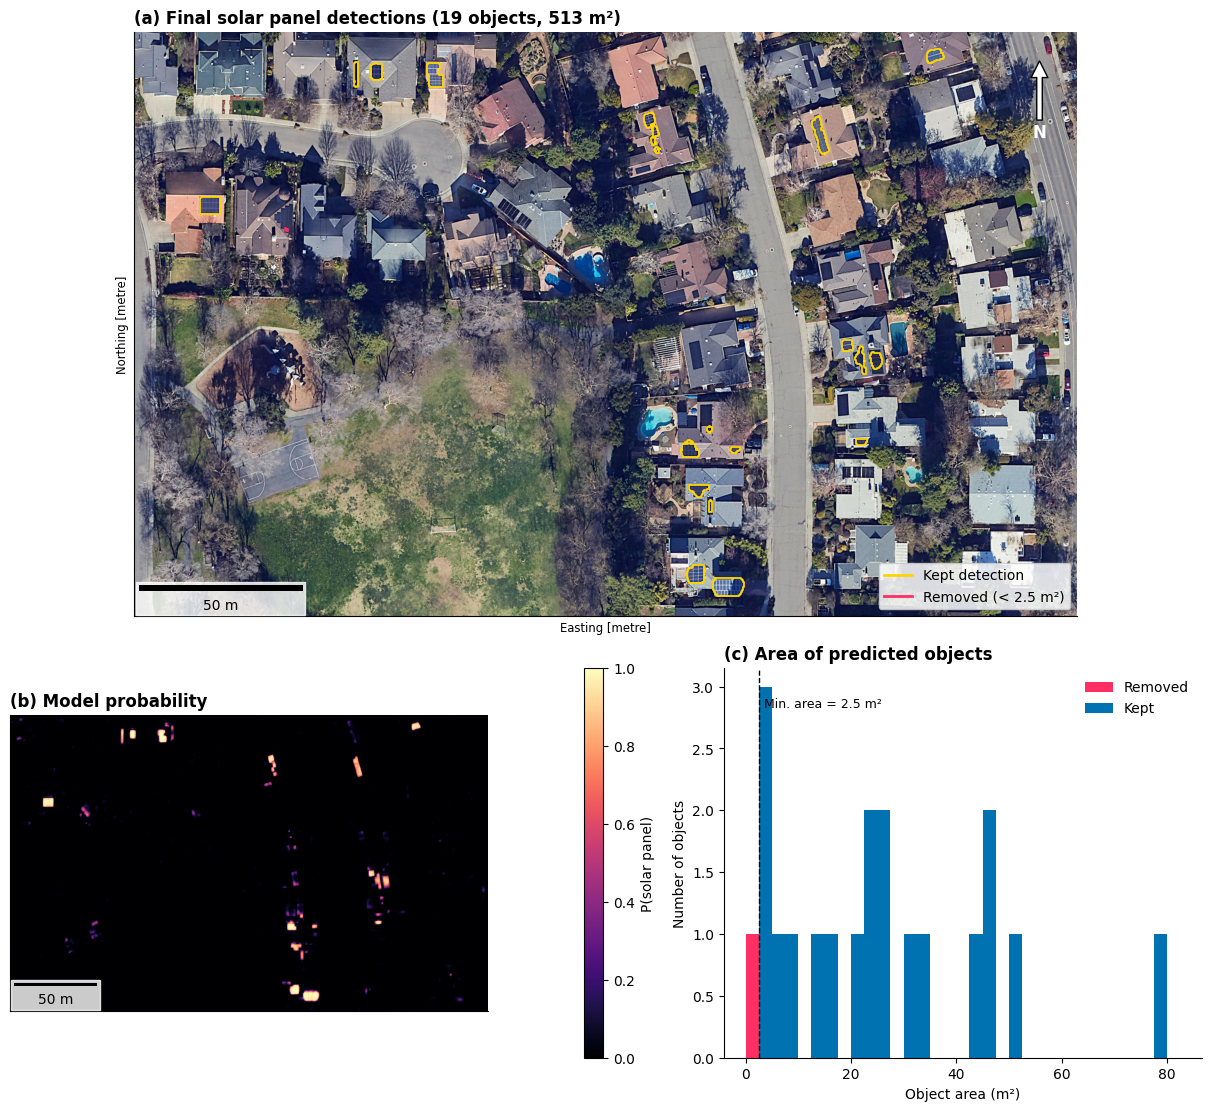

In [ ]:
!pip install -q matplotlib-scalebar
import rasterio, numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from pyproj import Transformer

min_area = 2.5

# --- Load imagery and probability map ---
with rasterio.open(test_raster_path) as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0).astype(float)
    crs = src.crs
    b = src.bounds
    extent = [b.left, b.right, b.bottom, b.top]
rgb = rgb / 255 if rgb.max() > 1 else rgb
rgb = np.clip(rgb, 0, 1)

with rasterio.open(probability_path) as src:
    prob = src.read(2 if src.count >= 2 else 1).astype(float)
prob = prob / 255 if prob.max() > 1 else prob

# --- Scale bar: metres per map unit ---
lon, lat = Transformer.from_crs(crs, "EPSG:4326", always_xy=True).transform(
    (b.left + b.right) / 2, (b.bottom + b.top) / 2)
if crs.is_geographic:
    dx = 111320 * np.cos(np.radians(lat))
elif crs.to_epsg() == 3857:
    dx = np.cos(np.radians(lat))
else:
    dx = 1.0

kept = gdf_filtered.to_crs(crs)
removed = gdf_props[gdf_props["area_m2"] < min_area].to_crs(crs)

def north_arrow(ax):
    ax.annotate("N", xy=(0.96, 0.95), xytext=(0.96, 0.82), xycoords="axes fraction",
                ha="center", fontsize=12, fontweight="bold", color="white",
                arrowprops=dict(facecolor="white", edgecolor="black", width=4, headwidth=12))

fig = plt.figure(figsize=(12, 11), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.5, 1])

# (a) Final detections
ax = fig.add_subplot(gs[0, :])
ax.imshow(rgb, extent=extent)
kept.boundary.plot(ax=ax, color="#FFD400", linewidth=1.3)
if len(removed):
    removed.boundary.plot(ax=ax, color="#FF2E63", linewidth=1.3)
ax.set_title(f"(a) Final solar panel detections ({len(kept)} objects, "
             f"{kept['area_m2'].sum():.0f} m²)", loc="left", fontweight="bold")
ax.legend(handles=[Line2D([], [], color="#FFD400", lw=2, label="Kept detection"),
                   Line2D([], [], color="#FF2E63", lw=2, label=f"Removed (< {min_area} m²)")],
          loc="lower right", framealpha=0.85)
ax.add_artist(ScaleBar(dx, units="m", location="lower left", box_alpha=0.8))
north_arrow(ax)
ax.set_xticks([]); ax.set_yticks([])

# (b) Probability map
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(prob, extent=extent, cmap="magma", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label="P(solar panel)")
ax.set_title("(b) Model probability", loc="left", fontweight="bold")
ax.add_artist(ScaleBar(dx, units="m", location="lower left", box_alpha=0.8))
ax.set_xticks([]); ax.set_yticks([])

# (c) Area distribution
ax = fig.add_subplot(gs[1, 1])
areas = gdf_props["area_m2"]
bins = np.arange(0, areas.max() + 5, 2.5)
ax.hist([areas[areas < min_area], areas[areas >= min_area]], bins=bins, stacked=True,
        color=["#FF2E63", "#0072B2"], label=["Removed", "Kept"])
ax.axvline(min_area, color="black", ls="--", lw=1)
ax.text(min_area + 1, ax.get_ylim()[1] * 0.9, f"Min. area = {min_area} m²", fontsize=9)
ax.set_xlabel("Object area (m²)"); ax.set_ylabel("Number of objects")
ax.set_title("(c) Area of predicted objects", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.savefig("Q12_final_result.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

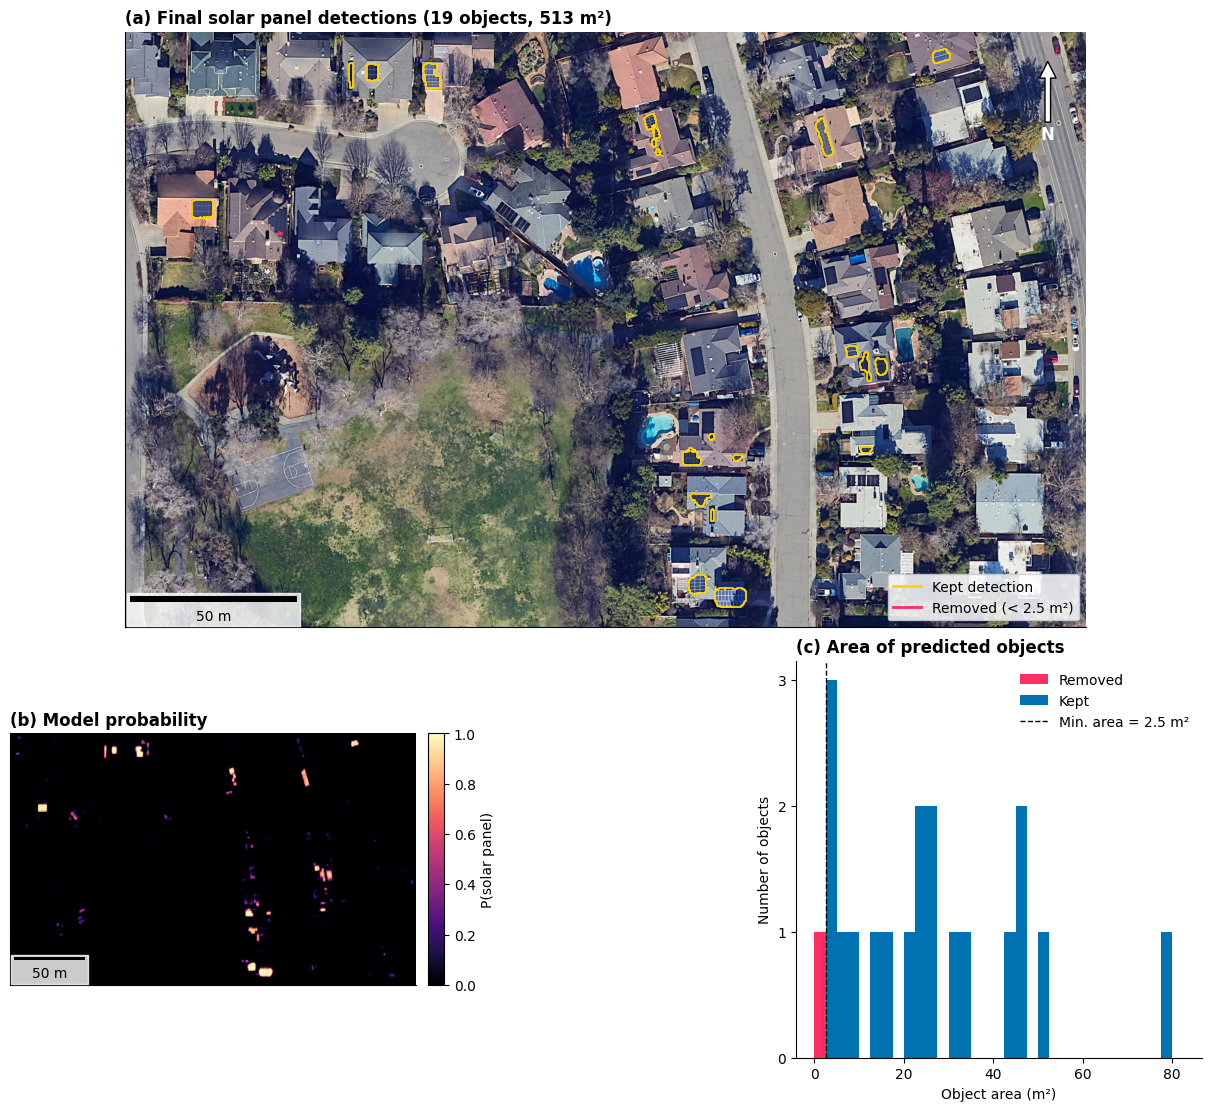

In [ ]:
from matplotlib.ticker import MaxNLocator

fig = plt.figure(figsize=(12, 11), constrained_layout=True)
fig.get_layout_engine().set(wspace=0.08)
gs = fig.add_gridspec(2, 3, height_ratios=[1.5, 1], width_ratios=[1, 0.12, 1])

# (a) Final detections
ax = fig.add_subplot(gs[0, :])
ax.imshow(rgb, extent=extent)
kept.boundary.plot(ax=ax, color="#FFD400", linewidth=1.3)
if len(removed):
    removed.boundary.plot(ax=ax, color="#FF2E63", linewidth=1.3)
ax.set_title(f"(a) Final solar panel detections ({len(kept)} objects, "
             f"{kept['area_m2'].sum():.0f} m²)", loc="left", fontweight="bold")
ax.legend(handles=[Line2D([], [], color="#FFD400", lw=2, label="Kept detection"),
                   Line2D([], [], color="#FF2E63", lw=2, label=f"Removed (< {min_area} m²)")],
          loc="lower right", framealpha=0.85)
ax.add_artist(ScaleBar(dx, units="m", location="lower left", box_alpha=0.8))
north_arrow(ax)
ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")

# (b) Probability map, with colour bar attached directly to the map
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(prob, extent=extent, cmap="magma", vmin=0, vmax=1)
cax = ax.inset_axes([1.03, 0, 0.04, 1])
fig.colorbar(im, cax=cax, label="P(solar panel)")
ax.set_title("(b) Model probability", loc="left", fontweight="bold")
ax.add_artist(ScaleBar(dx, units="m", location="lower left", box_alpha=0.8))
ax.set_xticks([]); ax.set_yticks([])

# (c) Area distribution (column 1 is an empty spacer)
ax = fig.add_subplot(gs[1, 2])
areas = gdf_props["area_m2"]
bins = np.arange(0, areas.max() + 5, 2.5)
ax.hist([areas[areas < min_area], areas[areas >= min_area]], bins=bins, stacked=True,
        color=["#FF2E63", "#0072B2"], label=["Removed", "Kept"])
ax.axvline(min_area, color="black", ls="--", lw=1, label=f"Min. area = {min_area} m²")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Object area (m²)"); ax.set_ylabel("Number of objects")
ax.set_title("(c) Area of predicted objects", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.savefig("Q12_final_result.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()